# Problem statement

AI chatbots have gained significant popularity recently, offering a wide range of functionalities for users to utilise for various tasks. There are many technological and operational measurements related to chatbot performance. Data analysts from AI research organisations are aiming to find suitable machine learning methods to predict chatbot performance based on these factors. 

In this study, LLM-based system features are provided for machine learning model training to predict two key performance metrics of a chatbot: TARGET_Capacity and TARGET_CaseCount. These represent the chatbot's ability to handle conversation length and the capacity to process tasks simultaneously.

The training process will include exploratory data analysis (EDA), data preprocessing, applying different regression models, and tuning the models with regularization techniques. Various regression models, including Linear, Polynomial, and Poisson Regression, will be applied to evaluate their prediction accuracy for each target, assessing each model's performance based on defined metrics. Additionally, a regression model capable of predicting both targets with a single model will also be evaluated. Ultimately, the goal is to identify the optimal model with low complexity and stable prediction accuracy.



## 1. Exploratory Data Analysis (EDA)
The provided dataset will be imported and explored in this section, including feature summary statistics, checking for missing values, feature distribution analysis, correlation analysis, relationship between features and the target, and outlier detection. Exploring these properties can help with decisions for the next steps in data preprocessing and model training.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('Data.csv', sep=',', decimal='.', index_col=0)
df.head()


,TARGET_Capacity,TARGET_CaseCount,Country,Year,Status,SystemFailureRate,ModelFailureRate-T,ModelFailureRate-NT,InferenceLatency,ComputeUtilizationRate,...,AIDevExpPercent,PatchCoverageRate,SystemVulnerabilityScore,GlobalAdoptionIndex,ActiveUserBase,TeenQueryEfficiency,ChildQueryEfficiency,FundingDiversityIndex,DatasetDiversityScore,Complexity
RecordID,,,,,,,,,,,,,,,,,,,,,
1,54.5,19,146,2007,0,291,306,276,85,0.02,...,8.70,58.0,0.1,28.33,257798,19.3,19.5,0.396,2.810694,1.152688
2,58.5,23,146,2006,0,293,286,300,87,0.02,...,8.79,5.0,0.1,245.44,24118979,19.5,19.7,0.381,2.607681,1.140279
3,53.9,18,146,2005,0,295,326,264,87,0.01,...,8.82,41.0,0.1,222.58,2364851,19.7,19.9,0.373,2.549510,1.127205
4,58.4,22,146,2004,0,3,2,4,88,0.01,...,7.76,36.0,0.1,210.39,21979923,19.9,2.2,0.341,2.489980,1.114043
5,55.2,19,146,2003,0,316,312,320,88,0.01,...,7.80,33.0,0.1,131.60,2966463,2.1,2.4,0.340,2.428992,1.100471


In [6]:
# Checking data type
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2071 entries, 1 to 2071
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   TARGET_Capacity           2071 non-null   float64
 1   TARGET_CaseCount          2071 non-null   int64  
 2   Country                   2071 non-null   int64  
 3   Year                      2071 non-null   int64  
 4   Status                    2071 non-null   int64  
 5   SystemFailureRate         2071 non-null   int64  
 6   ModelFailureRate-T        2071 non-null   int64  
 7   ModelFailureRate-NT       2071 non-null   int64  
 8   InferenceLatency          2071 non-null   int64  
 9   ComputeUtilizationRate    2071 non-null   float64
 10  AIInfraExpPercent         2071 non-null   float64
 11  SecurityBreachIncidents   2071 non-null   int64  
 12  IntegrationEfficiency     2071 non-null   float64
 13  UptimeReliabilityIndex    2071 non-null   int64  
 14  AILearningSta

In [7]:
# Feature tatistics
df.describe()

,TARGET_Capacity,TARGET_CaseCount,Country,Year,Status,SystemFailureRate,ModelFailureRate-T,ModelFailureRate-NT,InferenceLatency,ComputeUtilizationRate,...,AIDevExpPercent,PatchCoverageRate,SystemVulnerabilityScore,GlobalAdoptionIndex,ActiveUserBase,TeenQueryEfficiency,ChildQueryEfficiency,FundingDiversityIndex,DatasetDiversityScore,Complexity
count,2071.000000,2071.000000,2071.000000,2071.000000,2071.000000,2071.000000,2071.000000,2071.000000,2071.000000,2071.000000,...,2071.000000,2071.000000,2071.000000,2071.000000,2.071000e+03,2071.000000,2071.000000,2071.000000,2071.000000,2071.000000
mean,69.274505,33.328344,95.360212,2009.518590,0.185418,162.833897,161.908257,163.759536,33.079672,4.696379,...,5.883858,82.753259,1.632883,7352.742342,1.203741e+07,4.941284,4.977306,0.609551,3.372453,41.209264
std,9.482281,9.488328,54.861641,4.614147,0.388730,118.872170,119.442235,118.800292,135.832868,4.205888,...,2.554965,23.130969,4.782325,15219.978663,6.391797e+07,4.697830,4.785532,0.216532,0.590832,52.600482
min,37.300000,1.000000,0.000000,2002.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.010000,...,0.370000,2.000000,0.100000,1.880000,3.400000e+01,0.100000,0.100000,0.000000,0.000000,0.146228
25%,63.000000,27.000000,50.000000,2006.000000,0.000000,74.000000,74.000000,74.000000,0.000000,0.615000,...,4.190000,78.000000,0.100000,413.730000,1.274450e+05,1.600000,1.500000,0.463000,3.065942,2.039788
50%,71.200000,35.000000,94.000000,2010.000000,0.000000,144.000000,142.000000,144.000000,3.000000,3.830000,...,5.640000,93.000000,0.100000,1410.670000,6.522310e+05,3.200000,3.300000,0.655000,3.449638,16.085911
75%,76.000000,40.000000,144.000000,2014.000000,0.000000,228.000000,228.000000,230.000000,22.000000,7.840000,...,7.430000,97.000000,0.800000,5811.295000,5.371104e+06,7.400000,7.400000,0.769500,3.741657,63.131947
max,92.700000,57.000000,192.000000,2017.000000,1.000000,699.000000,704.000000,722.000000,1800.000000,17.870000,...,17.600000,99.000000,50.600000,133473.470000,1.293859e+09,27.700000,28.600000,0.948000,4.381780,321.087408


In [8]:
# Check for missing values
if df.isnull().values.any():  
    print(df[df.isnull().any(axis=1)])  
else:  
    print("No missing values found.")  


No missing values found.


> <span style="font-size:1em;">✔</span> **Observations:** 
* Excluding the ID column, which will serve as the index, there are 23 features and 2071 rows of data, with no missing values.

* The two targets, `TARGET_Capacity` and `TARGET_CaseCount`, are of different data types: `TARGET_Capacity` is continuous numerical, while `TARGET_CaseCount` is discrete (count) numerical.

* Most features are numerical, only `Country` and `Status` are categorical data types, both represented with integers. `Status` is in binary format, so it will not require further encoding during preprocessing.

### Feature Distribution

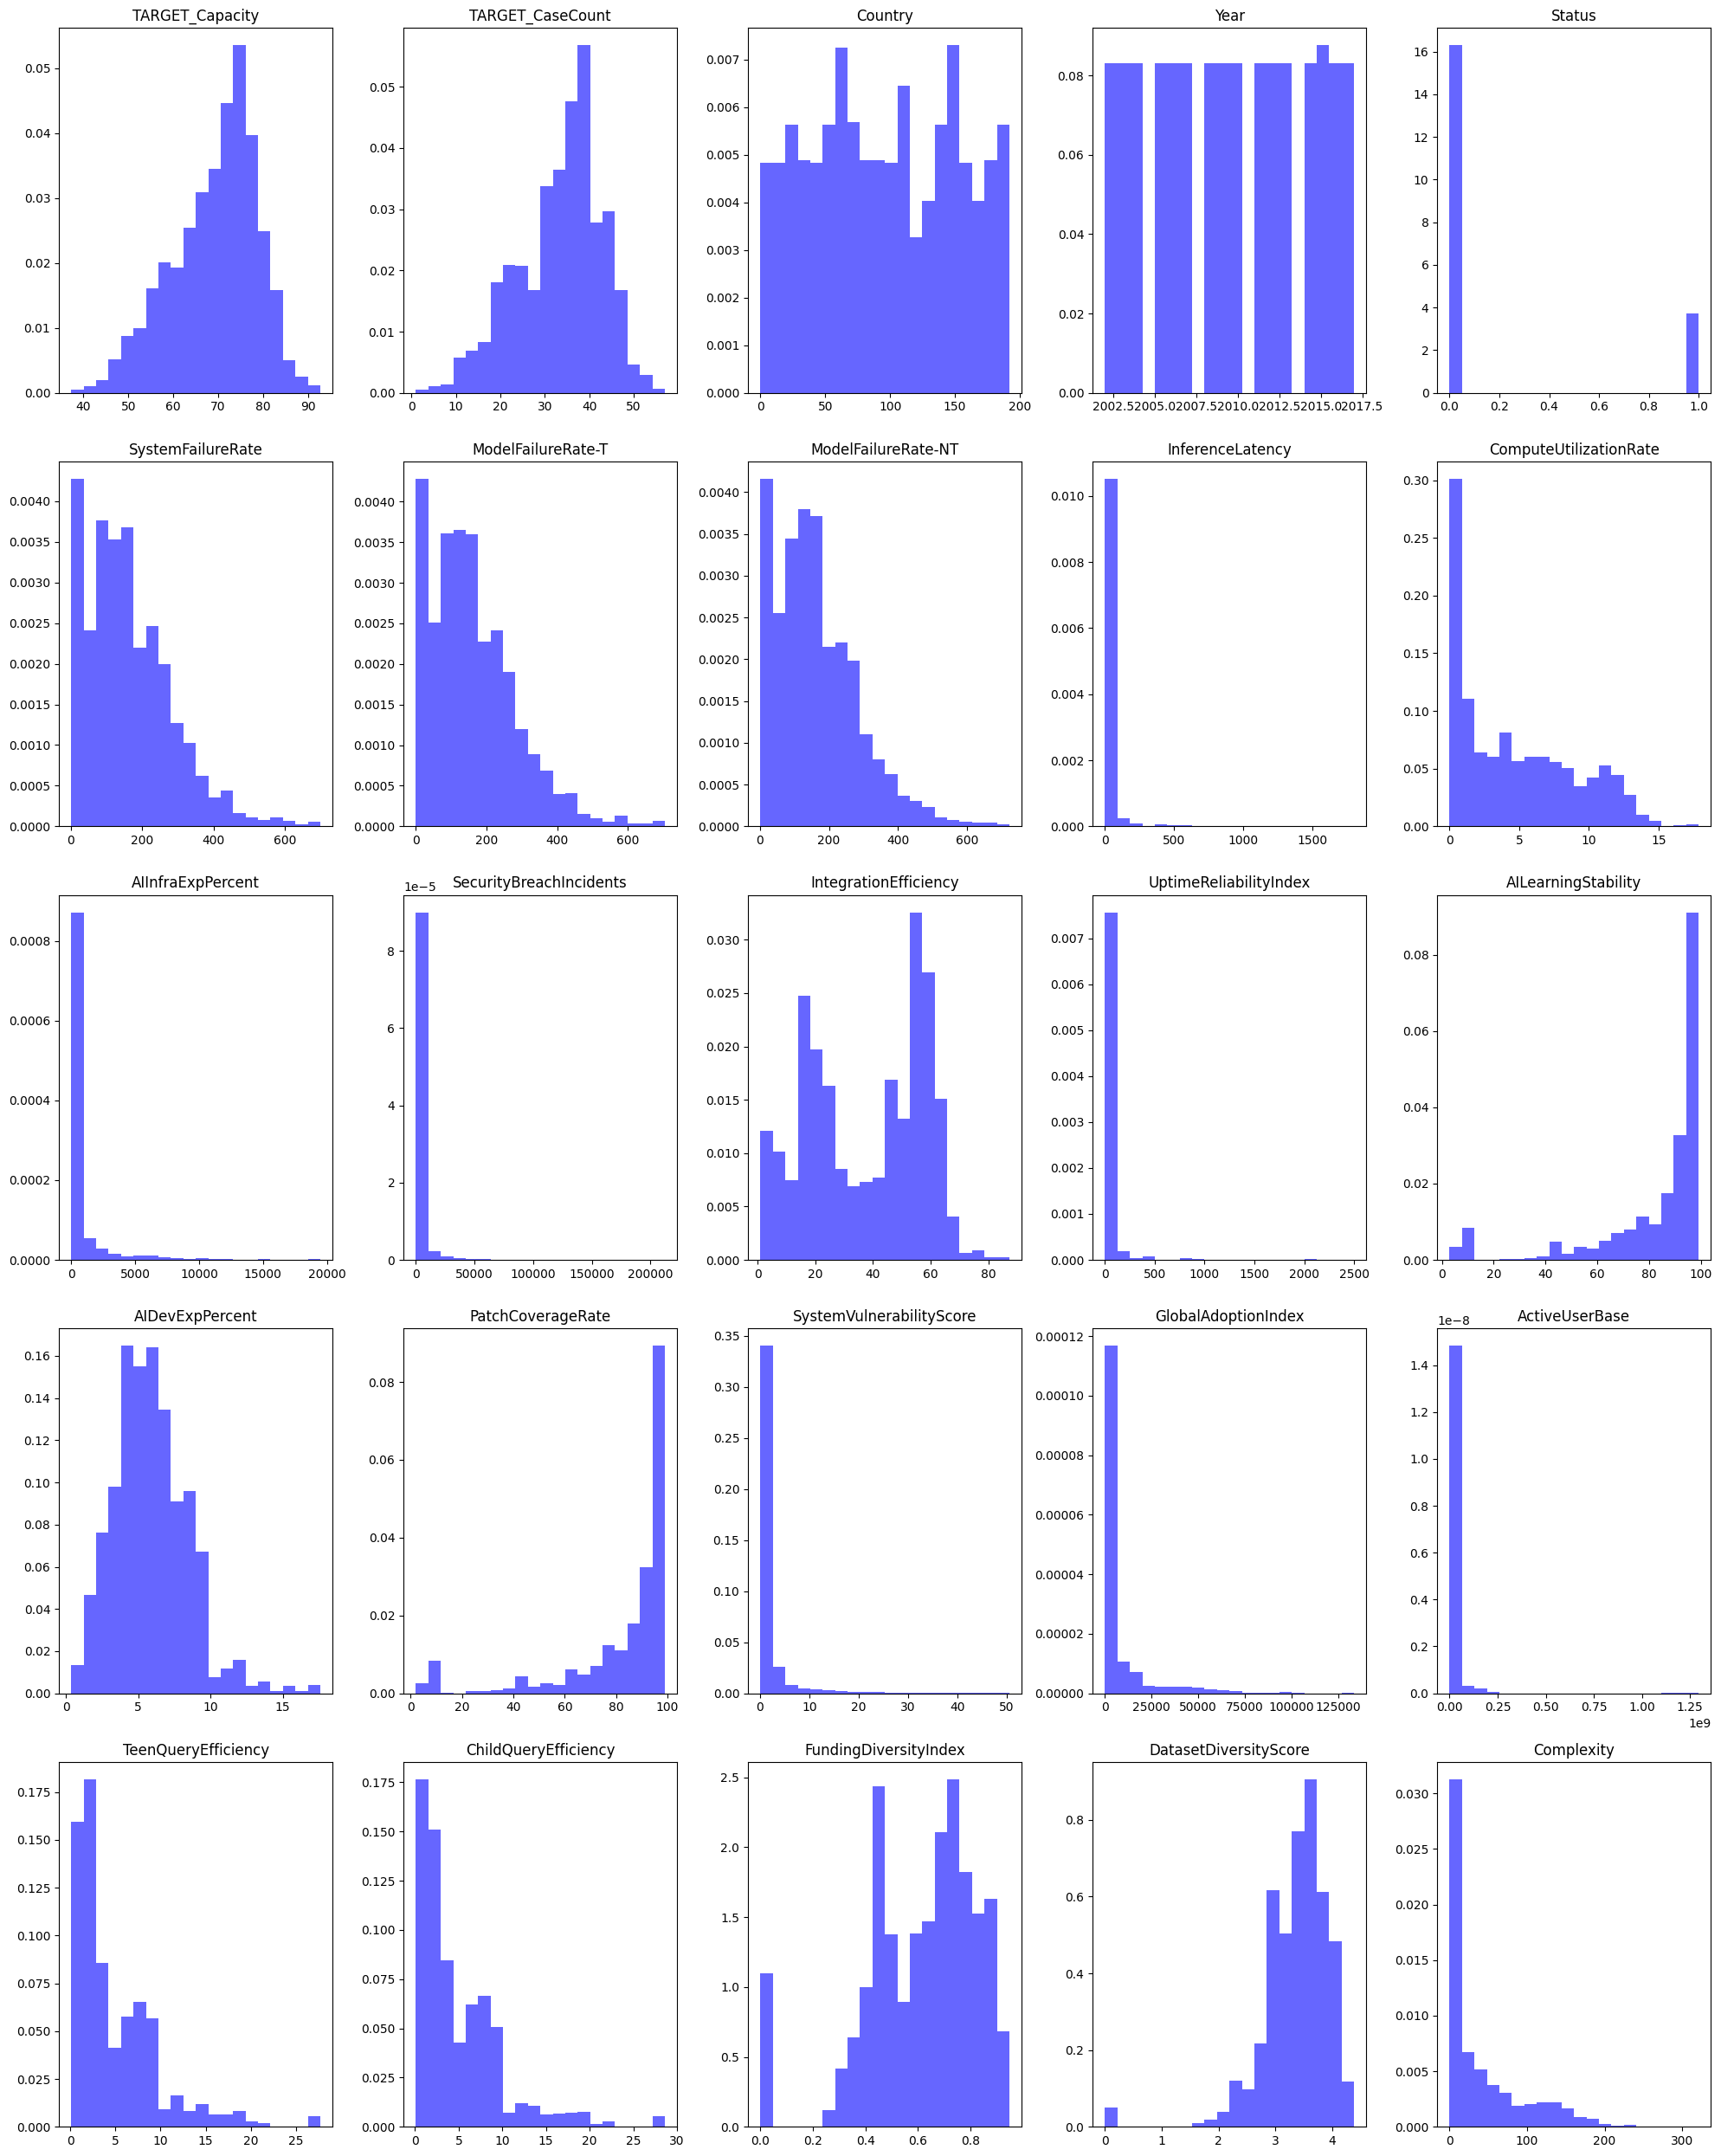

In [9]:
# Histogram of each Feature
plt.figure(figsize=(20,25))
for i, col in enumerate(df.columns):
    plt.subplot(5,5,i+1)
    plt.hist(df[col],bins=20, alpha=0.6, color='b', density=True)
    plt.title(col)
plt.tight_layout() 
plt.show()

In [10]:
# Check for highly skewed feature
skewness = df.skew()
highly_skewed = skewness[skewness.abs() > 1].index.tolist()
print(f"Highly skewed features: {highly_skewed}")

# Check unique catagory counts of 'Country' feature
country_count = df['Country'].nunique()
print(f"Unique country identifier count: {country_count}")

Highly skewed features: ['Status', 'SystemFailureRate', 'ModelFailureRate-T', 'ModelFailureRate-NT', 'InferenceLatency', 'AIInfraExpPercent', 'SecurityBreachIncidents', 'UptimeReliabilityIndex', 'AILearningStability', 'PatchCoverageRate', 'SystemVulnerabilityScore', 'GlobalAdoptionIndex', 'ActiveUserBase', 'TeenQueryEfficiency', 'ChildQueryEfficiency', 'DatasetDiversityScore', 'Complexity']
Unique country identifier count: 136


> <span style="font-size:1em;">✔</span> **Observations:** 
* The histogram of the two targets show similar distibution bahavour and distribution shape is close to normal distribution. 
* Many features are highly skewed. Excluding `Status`, as it's a binary data type, the highly skewed features are:

    - `SystemFailureRate`, `ModelFailureRate-T`, `ModelFailureRate-NT`, `InferenceLatency`, `AIInfraExpPercent`, `SecurityBreachIncidents`, `UptimeReliabilityIndex`, `AILearningStability`, `PatchCoverageRate`, `SystemVulnerabilityScore`, `GlobalAdoptionIndex`, `ActiveUserBase`, `TeenQueryEfficiency`, `ChildQueryEfficiency`, `DatasetDiversityScore`, `Complexity`

* The histograms also show that `FundingDiversityIndex` and `DatasetDiversityScore` contain data points far from the norm, potentially outliers.

* There are 136 unique country identifier in the `Country` feature.

### Feature Correlation 

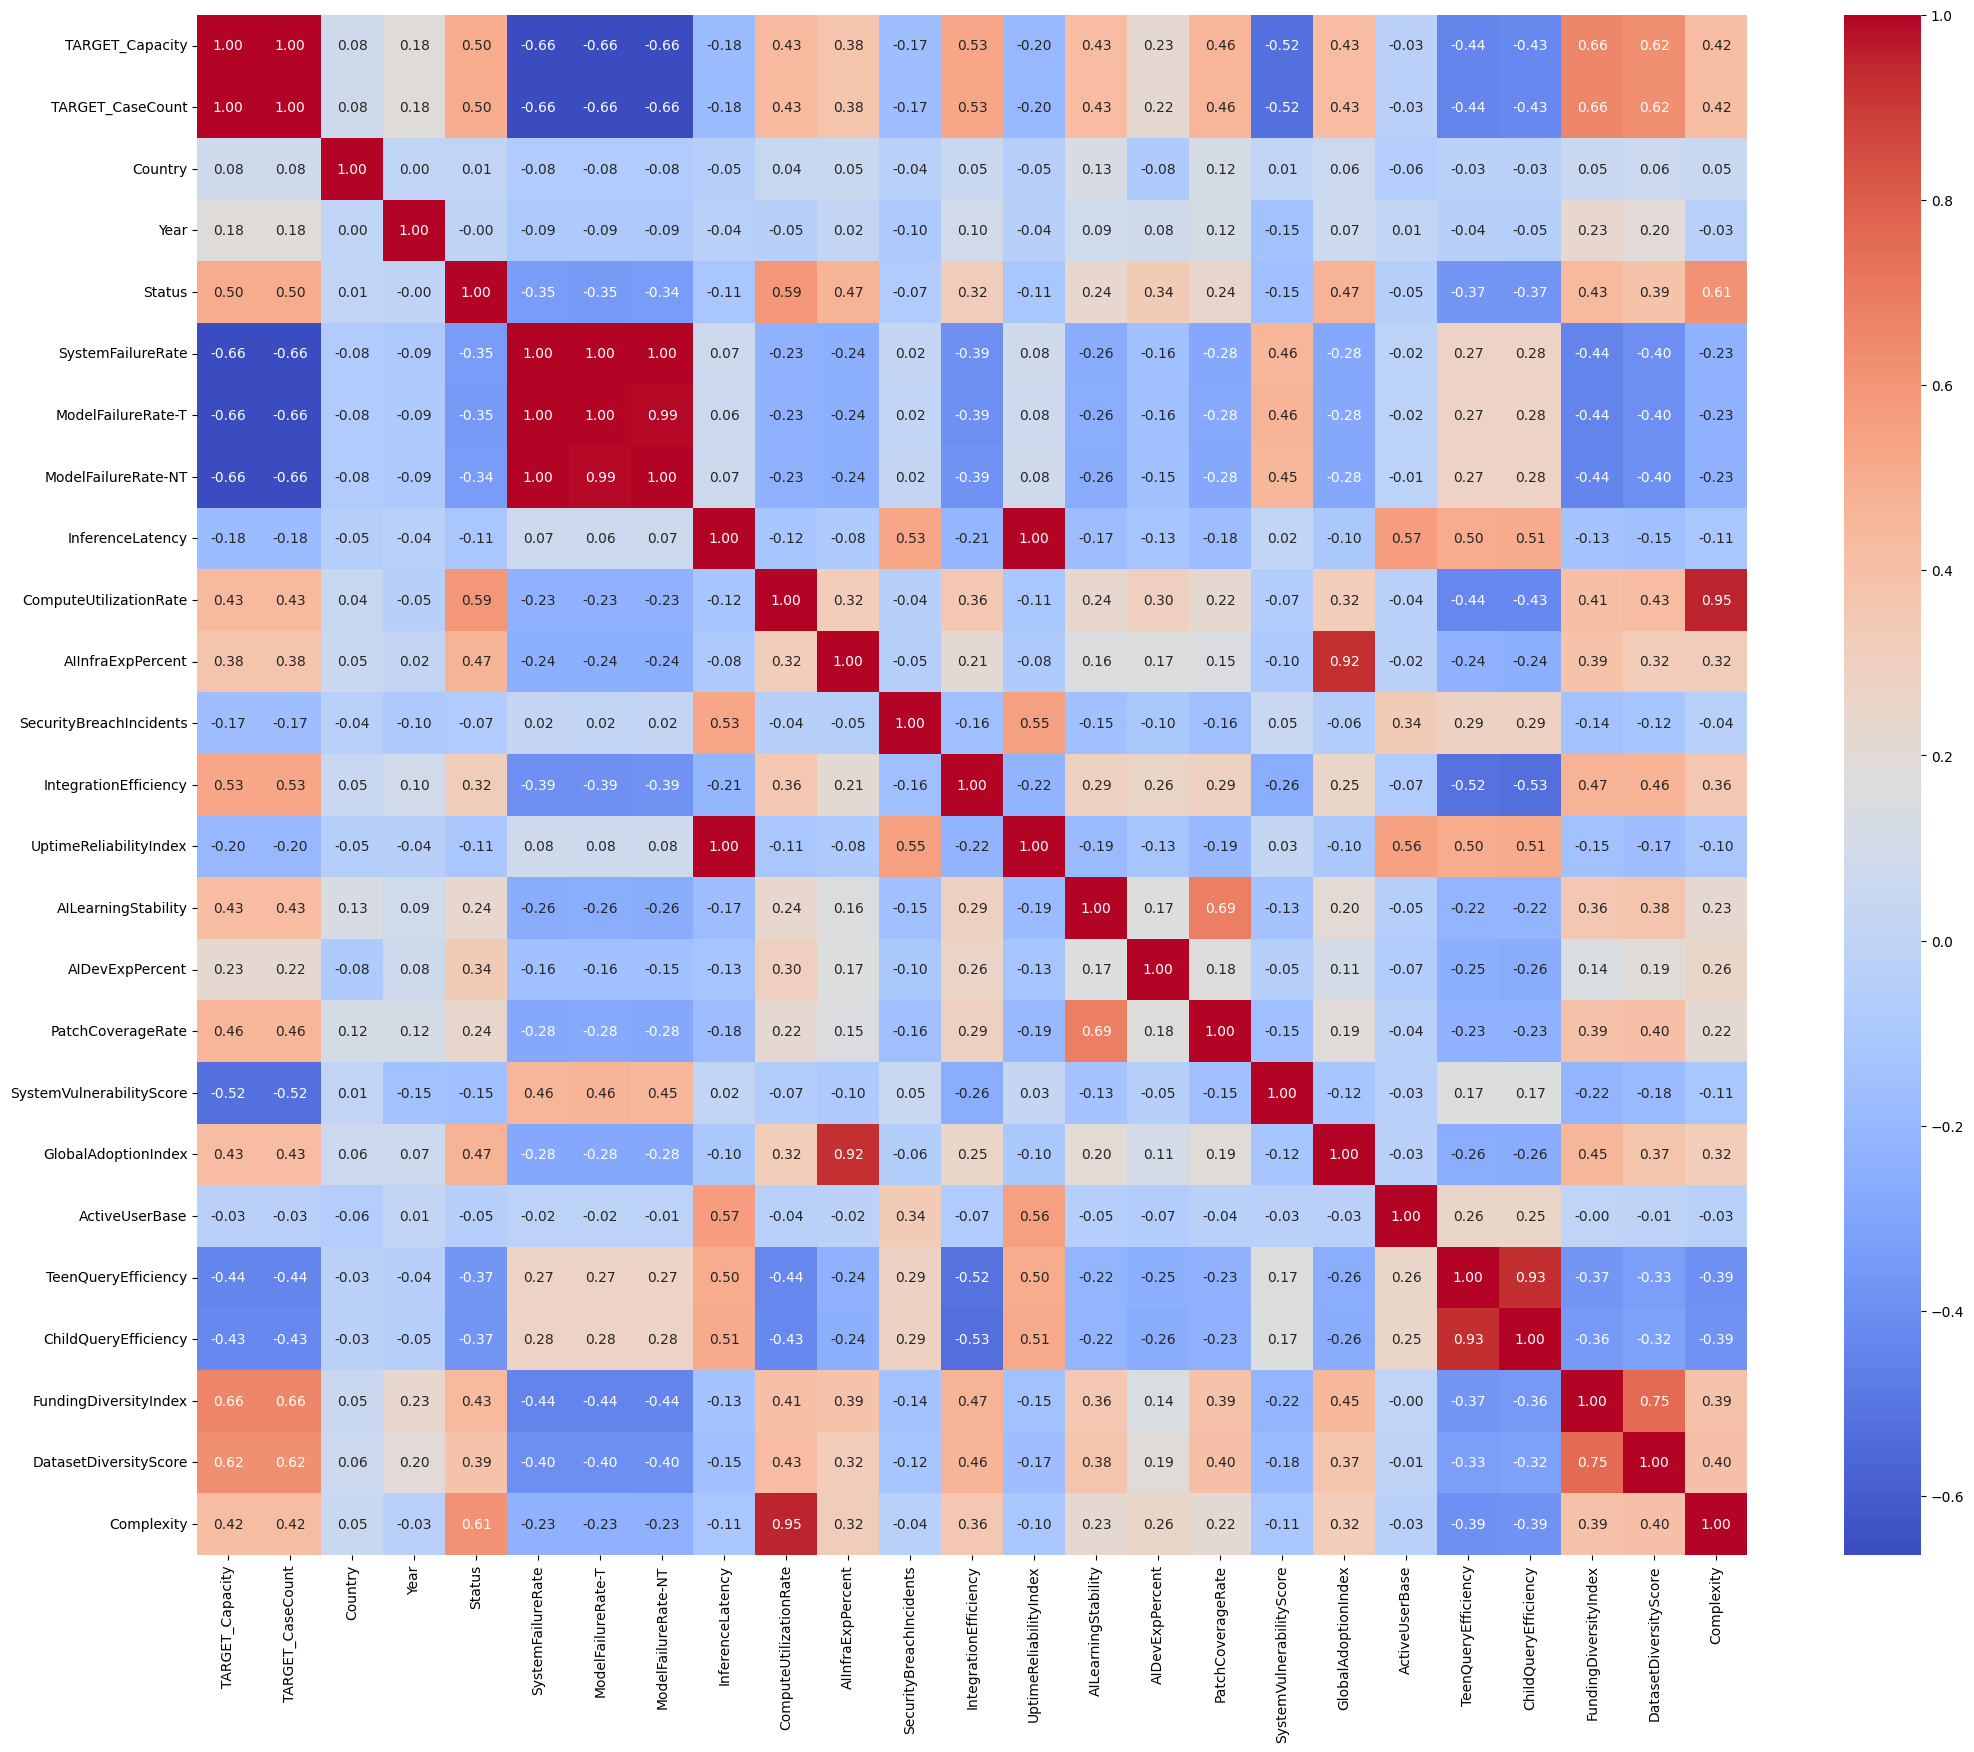

In [11]:
# Correlation heatmap
plt.figure(figsize=(25,20))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

Observations:
* The two target `Target_Capacity` and `Target_CaseCount` have a high corrilation of 1.

* The absolute correlation coefficients from the heat map that are greater than 0.6 are considered to indicate strong correlation. Therefore, Features that have a strong correlation with the two targets:

  - `SystemFailureRate`, `ModelFailureRate-T`, `ModelFailureRate-NT`, `FundingDiversityIndex`, `DatasetDiversityScore`   

* Features that have a correlation lower than 0.1 can be considered to have no correlation with the two targets:
  - `Country`, `ActiveUserBase`

### Relationship Between Features and Target

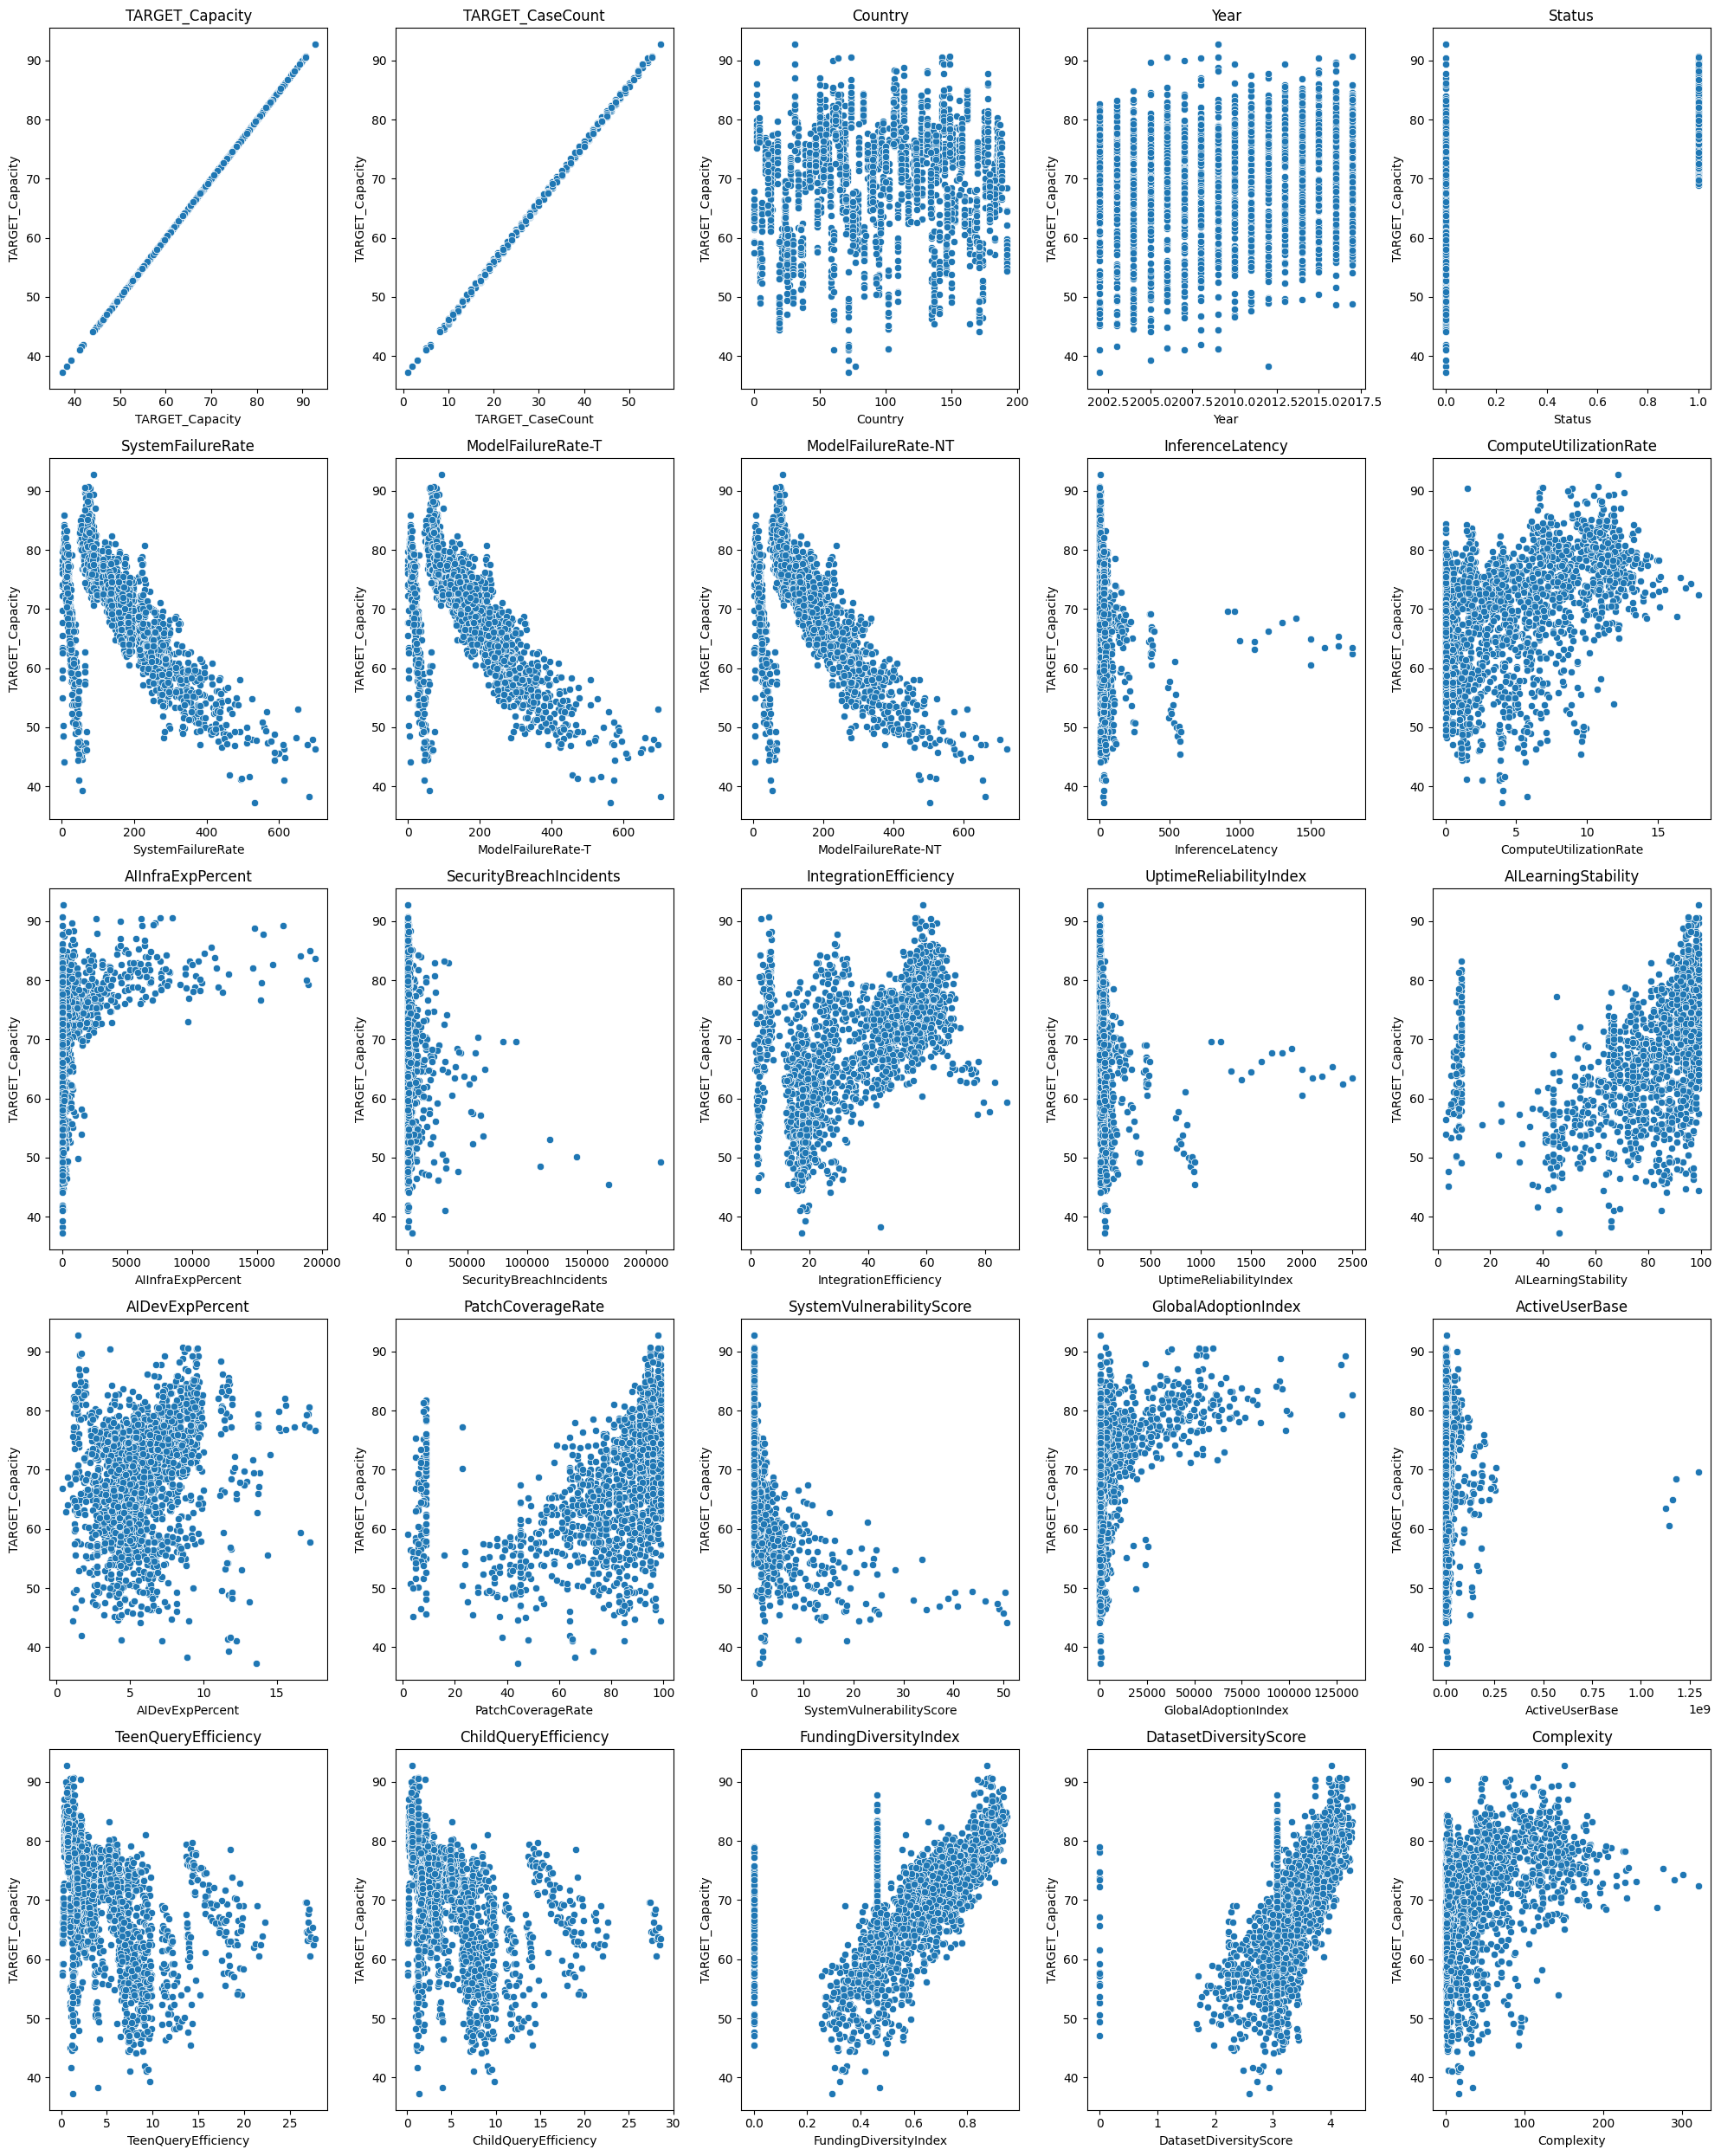

In [12]:
# Scatter plot of all features against TARGET_Capacity
import seaborn as sns
plt.figure(figsize=(20,25))
# for i, col in enumerate(df.columns[2:]):
for i, col in enumerate(df.columns):
    plt.subplot(5,5,i+1)
    sns.scatterplot(data=df, x=col, y='TARGET_Capacity')
    plt.title(col)
plt.tight_layout() 
plt.show()

> <span style="font-size:1em;">✔</span> **Observations:** 
* The two targets relation scatter plot show almost a perfect line. 

* The highly skewed features also have distribution patterns for higher values.

### Outliers Detection

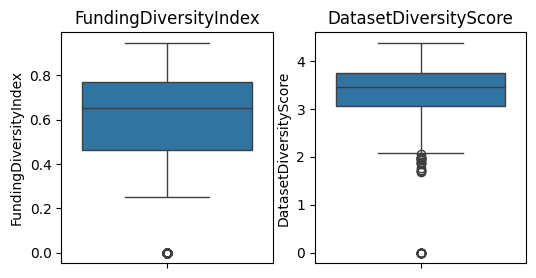

In [13]:
# Box plot for checking outliers
plt.figure(figsize=(6, 3))

boxplot_features = ['FundingDiversityIndex', 'DatasetDiversityScore']

for i, col in enumerate(boxplot_features):
    plt.subplot(1, 2, i + 1)  
    sns.boxplot(y=df[col]) 
    plt.title(col)
plt.show()

> <span style="font-size:1em;">✔</span> **Observations:** 
* There are some datapoints showing below the lower whisker of the box plot for the two features, which couuld be identified as outlieirs.

### EDA result Analysis and deriven conclusion
* Data pre-processing approach: 
  - Encoding: The `Country` feature needs encoding to handle its categorical data. Since `Country` has 136 unique identifiers, using One-Hot encoding would greatly increase complexity. Therefore, target encoding will be used instead.

  - Tranformation: The histograms shows there are many features highly skewed. However, the scatter plots show that these features also have distribution patterns for higher values. Therefore, these features will be later using power transform to reduce the skewness and make the data more balanced distribution.

  - Scaling: Min-max normalisation will be used so that all features contribute equally to the model's performance while maintaining the relationships between data points.
* Modeling Approach: 
  - Features such as `SystemFailureRate` and `DatasetDiversityScore` show strong correlations with both targets. Therefore, a linear regression model is assume to be suitable to fit `TARGET_Capacity`, while the count-based `TARGET_CaseCount` will be modeled using Poisson regression.
* Evaluation Metrics:
  - There are some outliers within the dataset, which will not be removed during preprocessing in this study. Therefore, MAE will be primarily used to compare prediction error To avoid being too sensitive to outliers.
  - RMSE will be used to calculate the generalisation gap to assess if the model is overfitting, and aim for a generalisation gap of less than 15%.
  - R² will also be used to determine if the model explains the data variance well enough, which is useful for tuning the model, and aim for an R² greater than 0.85.

## 2. Data Spliting and Pre- Processing

### Data Splitting
Holdout validation is used to split the dataset into 60/20/20 for training, validation, and testing.

Train dateset: (1242, 25)
Validate dataset: (414, 25)
Test dataset: (415, 25)


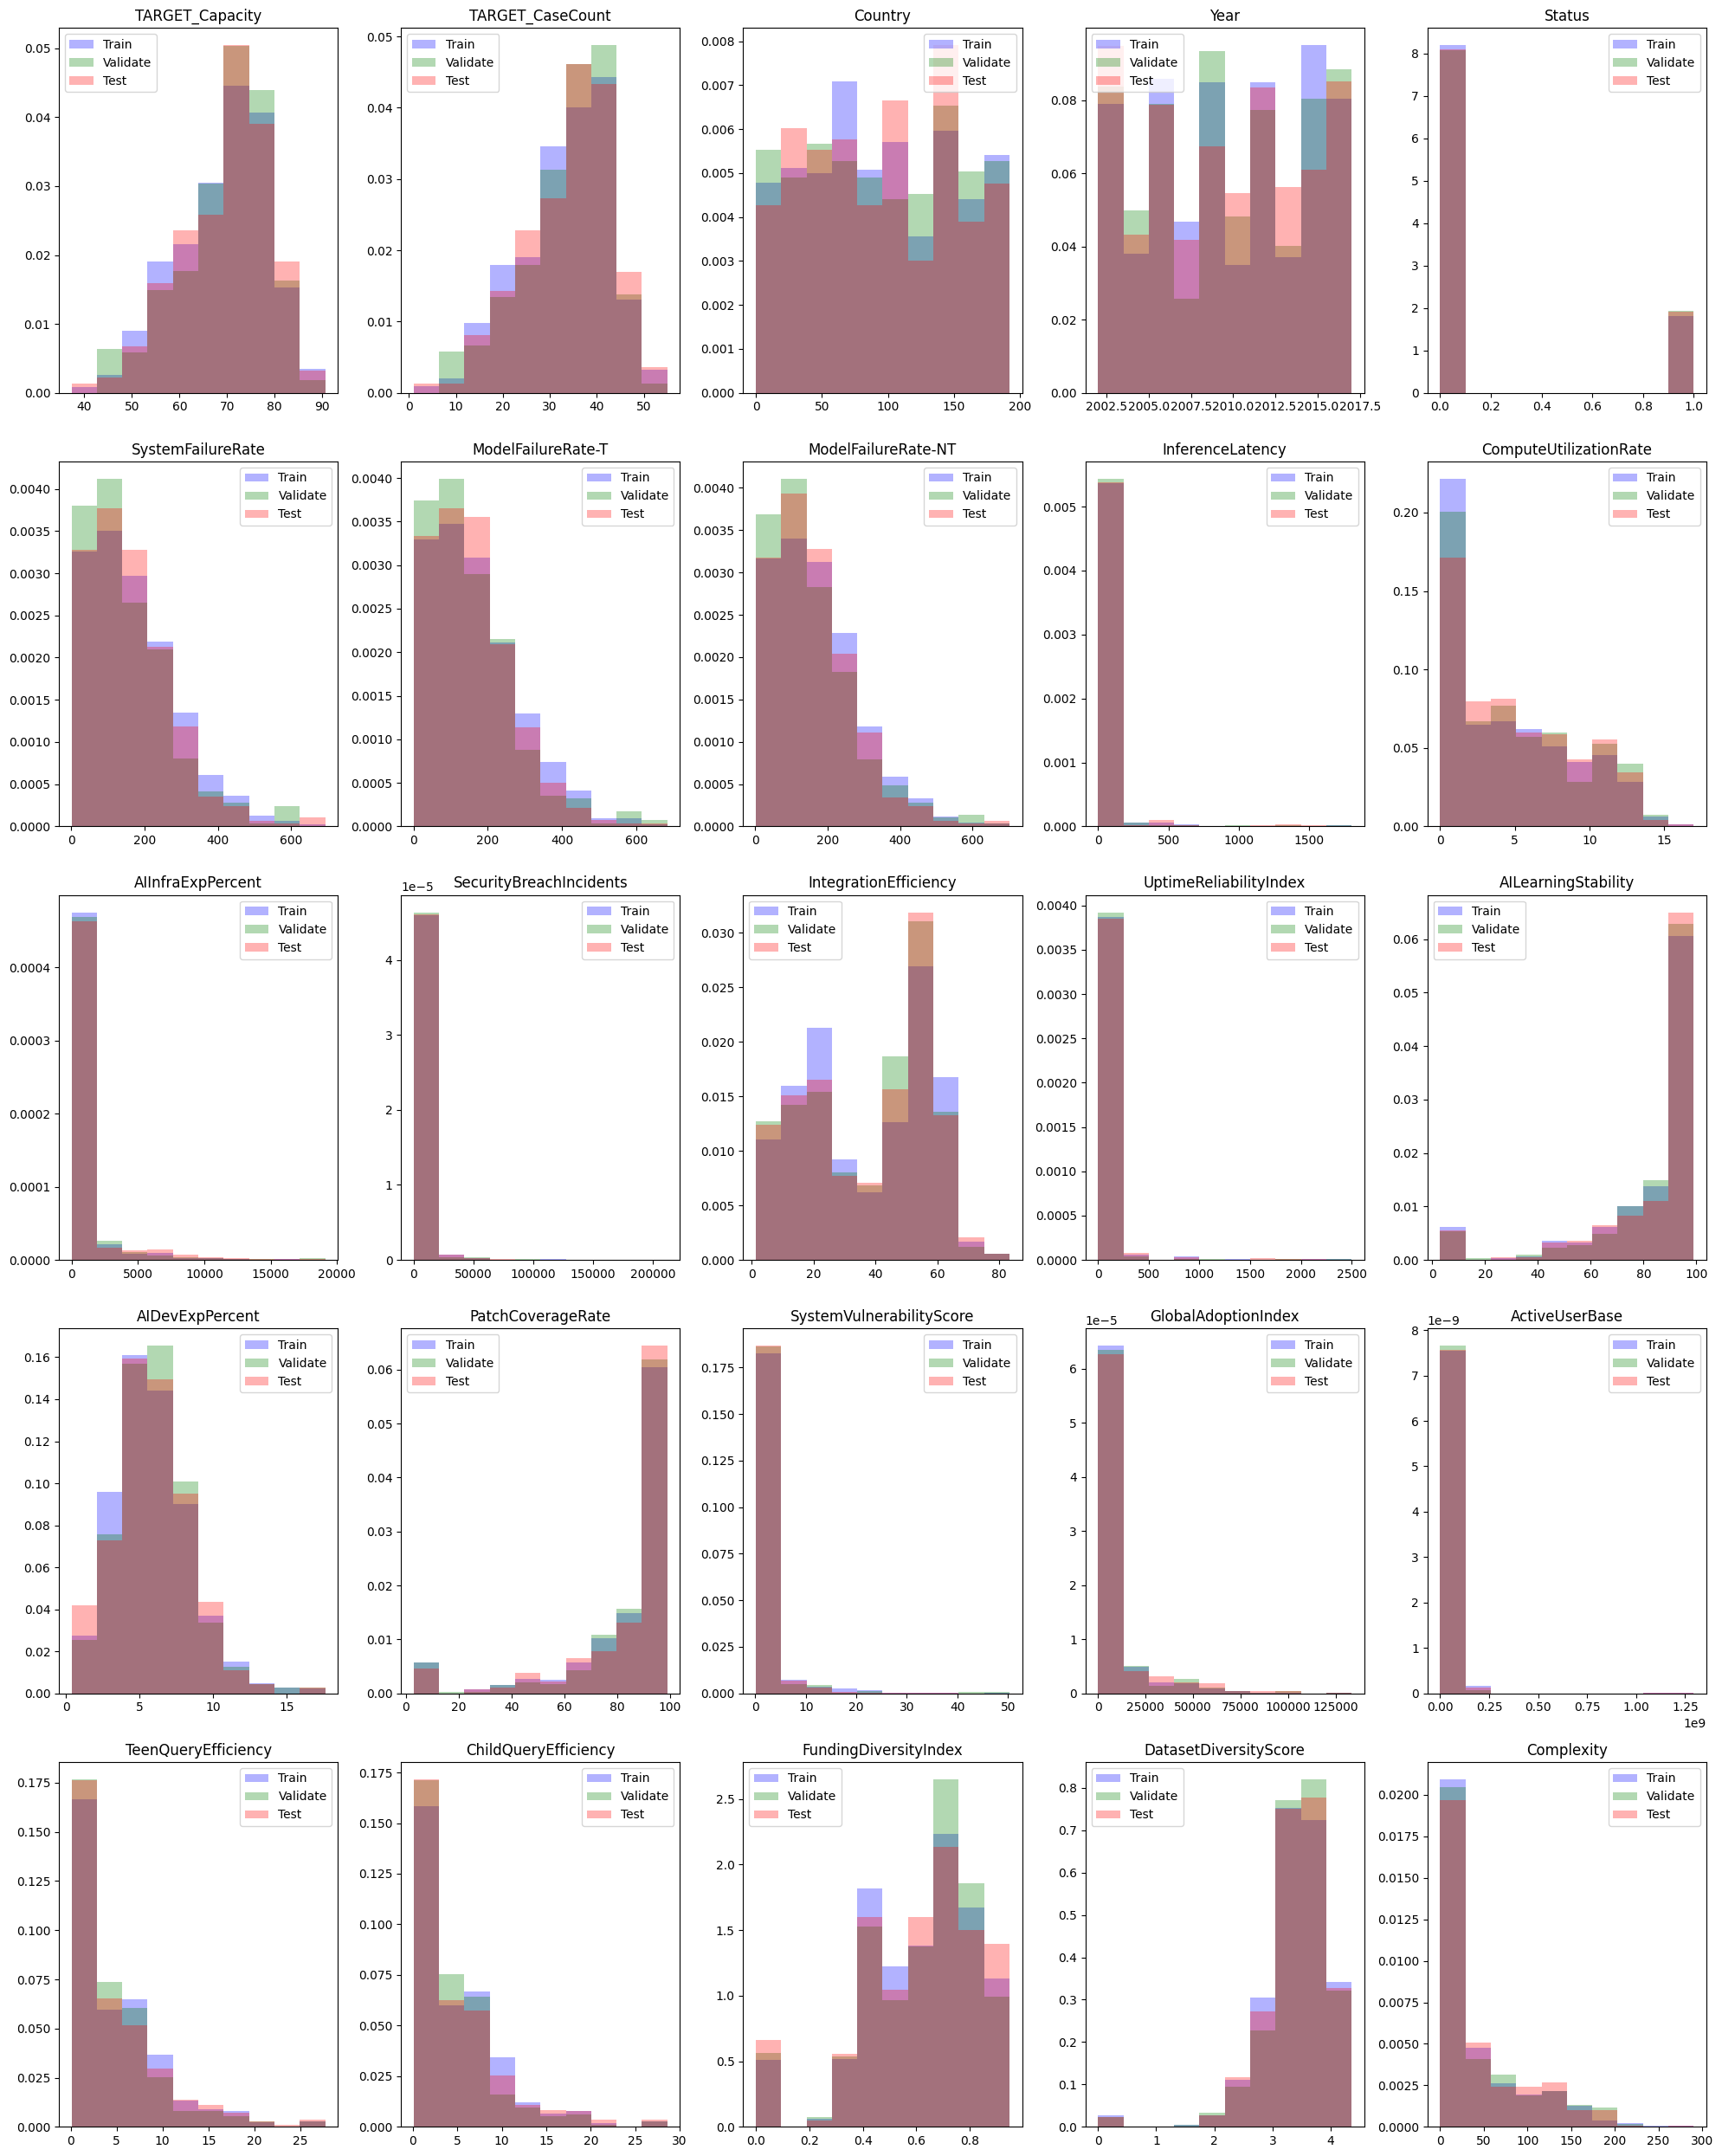

In [14]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, test_size=0.2, shuffle=True, random_state=34)
df_train, df_val = train_test_split(df_train, test_size=0.25, shuffle=True, random_state=34)
print(f"Train dateset: {df_train.shape}")
print(f"Validate dataset: {df_val.shape}")
print(f"Test dataset: {df_test.shape}")

# Check if split even 
plt.figure(figsize=(20, 25))
for i, col in enumerate(df_train.columns):
    plt.subplot(5, 5, i+1)
    _, bins, _ = plt.hist(df_train[col], alpha=0.3, color='b', density=True, label='Train')
    plt.hist(df_val[col], bins=bins, alpha=0.3, color='g', density=True, label='Validate')
    plt.hist(df_test[col], bins=bins, alpha=0.3, color='r', density=True, label='Test')
    plt.title(col)
    plt.legend() 
plt.tight_layout() 
plt.show()

# Seperate target and features
X_train = df_train.drop(columns=['TARGET_Capacity', 'TARGET_CaseCount'])
X_val = df_val.drop(columns=['TARGET_Capacity', 'TARGET_CaseCount'])
X_test = df_test.drop(columns=['TARGET_Capacity', 'TARGET_CaseCount'])
y_train = df_train[['TARGET_Capacity', 'TARGET_CaseCount']]
y_val = df_val[['TARGET_Capacity', 'TARGET_CaseCount']]
y_test = df_test[['TARGET_Capacity', 'TARGET_CaseCount']]


### Data Transform and Normalize
A power transform is used to make skewed features more Gaussian-like, followed by min-max scaling to make the data more suitable for modeling.

In [15]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PowerTransformer

skewed_features = ['SystemFailureRate', 'ModelFailureRate-T', 'ModelFailureRate-NT', 'InferenceLatency', 'AIInfraExpPercent', 'SecurityBreachIncidents', 'UptimeReliabilityIndex',
                    'AILearningStability', 'PatchCoverageRate', 'SystemVulnerabilityScore', 'GlobalAdoptionIndex', 'ActiveUserBase', 'TeenQueryEfficiency', 'ChildQueryEfficiency', 'DatasetDiversityScore', 'Complexity']

X_train_N = X_train.copy()
X_val_N = X_val.copy()
X_test_N = X_test.copy()

# Apply PowerTransformer to skewed features
powertransformer = PowerTransformer(method='yeo-johnson', standardize=False)
X_train_N[skewed_features] = powertransformer.fit_transform(X_train[skewed_features])
X_val_N[skewed_features] = powertransformer.transform(X_val[skewed_features])
X_test_N[skewed_features] = powertransformer.transform(X_test[skewed_features])

# Apply MinMaxScaler to all features
minmaxscaler = MinMaxScaler().fit(X_train_N)
X_train_N = X_train_N.astype(float)
X_val_N = X_val_N.astype(float)
X_test_N = X_test_N.astype(float)
X_train_N.iloc[:, :] = minmaxscaler.transform(X_train_N)
X_val_N.iloc[:, :] = minmaxscaler.transform(X_val_N)
X_test_N.iloc[:, :] = minmaxscaler.transform(X_test_N)


### Principal Component Analysis (PCA)
A copy of the dataset using PCA for dimensionality reduction is prepared for model comparison. The number of components is initially set to achieve 95% variance and will be further tuned based on performance evaluation.

In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_train_PCA = pca.fit_transform(X_train_N)
X_val_PCA = pca.transform(X_val_N) 
X_test_PCA = pca.transform(X_test_N) 

# Convert the PCA results back to a DataFrame
X_train_PCA = pd.DataFrame(X_train_PCA, index=X_train_N.index, columns=[f'PC{i+1}' for i in range(X_train_PCA.shape[1])])
X_val_PCA = pd.DataFrame(X_val_PCA, index=X_val_N.index, columns=[f'PC{i+1}' for i in range(X_val_PCA.shape[1])])
X_test_PCA = pd.DataFrame(X_test_PCA, index=X_test_N.index, columns=[f'PC{i+1}' for i in range(X_test_PCA.shape[1])])

print(f"Number of PCA components: {pca.n_components_}")


Number of PCA components: 13


## 3. Baseline development (Linear regression and Poisson Regression)

### Linear regression


--- Linear Regression Using All Features ---
Mean Absolute Error (MAE): 3.37
Training data prediction (RMSE): 4.27
Validation data prediction (RMSE): 4.43
Generalization Gap: 3.66%
R-squared (R2): 0.77
--- Linear Regression Using PCA Features (n_components=0.95) ---
Mean Absolute Error (MAE): 3.58
Training data prediction (RMSE): 4.40
Validation data prediction (RMSE): 4.63
Generalization Gap: 5.27%
R-squared (R2): 0.75


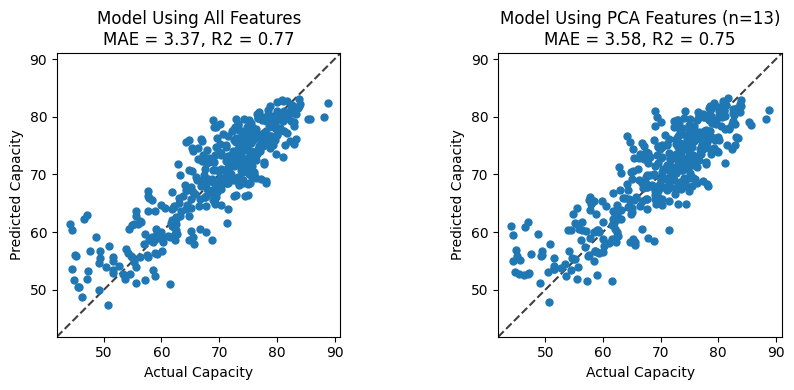

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Apply linear regression for 'Target_capacity' on all features
linear_model = LinearRegression().fit(X_train_N, y_train['TARGET_Capacity'])
y_train_N_pred = linear_model.predict(X_train_N)
y_val_N_pred = linear_model.predict(X_val_N)

val_N_mae = mean_absolute_error(y_val['TARGET_Capacity'], y_val_N_pred)
train_N_rmse = np.sqrt(mean_squared_error(y_train['TARGET_Capacity'], y_train_N_pred))
val_N_rmse = np.sqrt(mean_squared_error(y_val['TARGET_Capacity'], y_val_N_pred))
val_N_r2 = r2_score(y_val['TARGET_Capacity'], y_val_N_pred)

print("--- Linear Regression Using All Features ---")
print(f"Mean Absolute Error (MAE): {val_N_mae:.2f}")
print(f'Training data prediction (RMSE): {train_N_rmse:.2f}')
print(f'Validation data prediction (RMSE): {val_N_rmse:.2f}')
print(f'Generalization Gap: {abs(val_N_rmse - train_N_rmse)*100/train_N_rmse:.2f}%')
print(f'R-squared (R2): {val_N_r2:.2f}')


# Apply linear regression for 'Target_capacity' on PCA features
linear_PCA_model = LinearRegression().fit(X_train_PCA, y_train['TARGET_Capacity'])
y_train_PCA_pred = linear_PCA_model.predict(X_train_PCA)
y_val_PCA_pred = linear_PCA_model.predict(X_val_PCA)

val_PCA_mae = mean_absolute_error(y_val['TARGET_Capacity'], y_val_PCA_pred)
train_PCA_rmse = np.sqrt(mean_squared_error(y_train['TARGET_Capacity'], y_train_PCA_pred))
val_PCA_rmse = np.sqrt(mean_squared_error(y_val['TARGET_Capacity'], y_val_PCA_pred))
val_PCA_r2 = r2_score(y_val['TARGET_Capacity'], y_val_PCA_pred)

print("--- Linear Regression Using PCA Features (n_components=0.95) ---")
print(f"Mean Absolute Error (MAE): {val_PCA_mae:.2f}")
print(f'Training data prediction (RMSE): {train_PCA_rmse:.2f}')
print(f'Validation data prediction (RMSE): {val_PCA_rmse:.2f}')
print(f'Generalization Gap: {abs(val_PCA_rmse - train_PCA_rmse)*100/train_PCA_rmse:.2f}%')
print(f'R-squared (R2): {val_PCA_r2:.2f}')

# Compare performace with baseline
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

titles = ["Model Using All Features", "Model Using PCA Features (n=13)"]
predictions = [y_val_N_pred, y_val_PCA_pred]
metrics = [(val_N_mae, val_N_r2), (val_PCA_mae, val_PCA_r2)]

for ax, title, pred, (rmse, r2) in zip(axes, titles, predictions, metrics):
    ax.scatter(y_val['TARGET_Capacity'], pred, s=25, zorder=10)
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]), 
        np.max([ax.get_xlim(), ax.get_ylim()]), 
    ]
    ax.plot(lims, lims, 'k--', alpha=0.75, zorder=0)
    ax.set_aspect('equal')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_title(f"{title}\nMAE = {round(rmse, 2)}, R2 = {round(r2, 2)}")
    ax.set_xlabel('Actual Capacity')
    ax.set_ylabel('Predicted Capacity')

plt.tight_layout()
plt.show()


> <span style="font-size:1em;">✔</span> **Observations:**
* The Linear Regression models with and without PCA show similar performance, with the model using all features slightly performing better than the model using PCA. It achieved a lower MAE (3.37 vs. 3.52), lower RMSE (4.43 vs. 4.57), and a slightly higher R2 score (0.77 vs. 0.75). 

* Both models demonstrated good generalization, with small generalization gaps (3.66% vs. 5.29%), indicating less overfitting. While PCA reduced dimensionality, it did not improve performance and actually decreased prediction accuracy.

### Parameter tuning - PCA components
The following parameter tuning will explore the performance of using different numbers of PCA components to train the linear regression model, aiming to find the optimal component count based on the R2 score.

When n_components = 23 train model has highest R^2: 0.7700075395984216


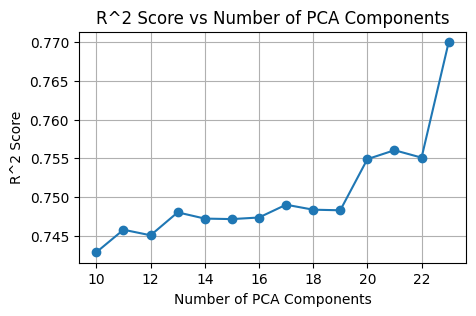

In [18]:
# Find best component number for PCA

r2_scores = []
n_components_range = range(10, 24)

for n in n_components_range:
    # Apply PCA
    pca = PCA(n_components=n)
    train_PCA = pca.fit_transform(X_train_N)
    val_PCA = pca.transform(X_val_N)
    train_PCA = pd.DataFrame(train_PCA, index=X_train_N.index)
    val_PCA = pd.DataFrame(val_PCA, index=X_val_N.index)
    
    # Train Linear Regression Model
    lr_model = LinearRegression().fit(train_PCA, y_train['TARGET_Capacity'])
    val_PCA_pred = lr_model.predict(val_PCA)
    
    # Compute R^2 score
    r2 = r2_score(y_val['TARGET_Capacity'], val_PCA_pred)
    r2_scores.append(r2)

best_index = np.argmax(r2_scores)
print(f'When n_components = {n_components_range[best_index]} train model has highest R^2: {r2_scores[best_index]}')

plt.figure(figsize=(5, 3))
plt.plot(n_components_range, r2_scores, marker='o', linestyle='-')
plt.xlabel('Number of PCA Components')
plt.ylabel('R^2 Score')
plt.title('R^2 Score vs Number of PCA Components')
plt.grid()
plt.show()

> <span style="font-size:1em;">✔</span> **Observations:**
* The grid serch for optimal PCA component show that only when selecting all features (23 components) will have a highest R2. Therefore, PCA is not suitable for applying in this model.
* We then plot the coefficients of the linear model and choose a suitable regularisation technuque to further improve the model.

### Coefficient Importance

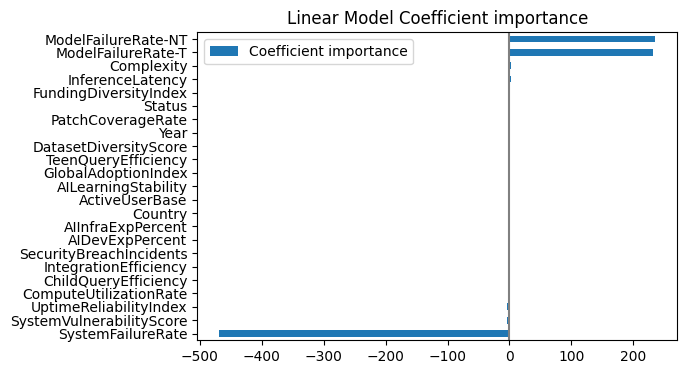

In [19]:
# Feature importance
coefs = pd.DataFrame(
    linear_model.coef_  * X_train_N.std(axis=0),
    columns=['Coefficient importance'], index=X_train_N.columns
)
coefs.sort_values(by=['Coefficient importance']).plot(kind='barh', figsize=(8, 4))
plt.title('Linear Model Coefficient importance')
plt.axvline(x=0, color='.5')
plt.subplots_adjust(left=.3)
plt.show()

### Parameter tuning - Regularization
Based on the coefficient importance plot, there are highly influential features such as `ModelFailureRate-NT`, `ModelFailureRate-T`, and `SystemFailureRate` that may dominate the model and lead to overfitting. Additionally, there is a multicollinearity issue, with correlations observed among features. Therefore, Ridge regression will be used to create a more balanced model and improve generalization.

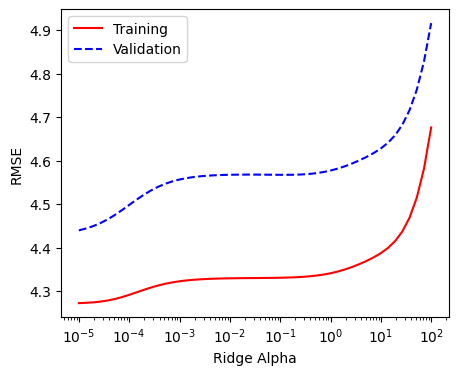

In [20]:
from sklearn.linear_model import Ridge

alphas = np.logspace(-5, 2)
train_errors = []
val_errors = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_N , y_train['TARGET_Capacity'])
    
    train_pred = ridge.predict(X_train_N)
    val_pred = ridge.predict(X_val_N)
    
    train_errors.append(np.sqrt(mean_squared_error(y_train['TARGET_Capacity'], train_pred)))
    val_errors.append(np.sqrt(mean_squared_error(y_val['TARGET_Capacity'], val_pred)))
    
plt.figure(figsize=(5, 4))
plt.plot([alpha for alpha in alphas],[tp for tp in train_errors], 'r-')
plt.plot([alpha for alpha in alphas],[vp for vp in val_errors], 'b--')
plt.xscale("log")
plt.ylabel('RMSE')
plt.xlabel('Ridge Alpha')
plt.legend(['Training','Validation'])
plt.show()

In [21]:
# Apply Ridge regularization with selected best alpha on all features

ridge_model = Ridge(alpha=0.0001).fit(X_train_N , y_train['TARGET_Capacity'])
train_ridge_pred = ridge_model.predict(X_train_N)
val_ridge_pred = ridge_model.predict(X_val_N)


val_ridge_mae = mean_absolute_error(y_val['TARGET_Capacity'], val_ridge_pred)
train_ridge_rmse = np.sqrt(mean_squared_error(y_train['TARGET_Capacity'], train_ridge_pred))
val_ridge_rmse = np.sqrt(mean_squared_error(y_val['TARGET_Capacity'], val_ridge_pred))
val_ridge_r2 = r2_score(y_val['TARGET_Capacity'], val_ridge_pred)

print("--- Linear Regression Using all features and Ridge regularization ---")
print(f"Mean Absolute Error (MAE): {val_ridge_mae:.2f}")
print(f'Training data prediction (RMSE): {train_ridge_rmse:.2f}')
print(f'Validation data prediction (RMSE): {val_ridge_rmse:.2f}')
print(f'Generalization Gap: {abs(val_ridge_rmse - train_ridge_rmse)*100/train_ridge_rmse:.2f}%')
print(f'R-squared (R2): {val_ridge_r2:.2f}')

--- Linear Regression Using all features and Ridge regularization ---
Mean Absolute Error (MAE): 3.44
Training data prediction (RMSE): 4.29
Validation data prediction (RMSE): 4.50
Generalization Gap: 4.82%
R-squared (R2): 0.76


> <span style="font-size:1em;">✔</span> **Observations:** 
* The graph shows that as the Ridge alpha approaches 0, the RMSE decreases, indicating that applying Ridge regularisation may not improve the model's performance.
* Therefore, we continue to use the model trained with all features and apply on the testing data.

### Evaluate trained model

--- Linear Regression Using All Features ---
Mean Absolute Error (MAE): 3.51
Testing data prediction (RMSE): 4.71
R-squared (R2): 0.75


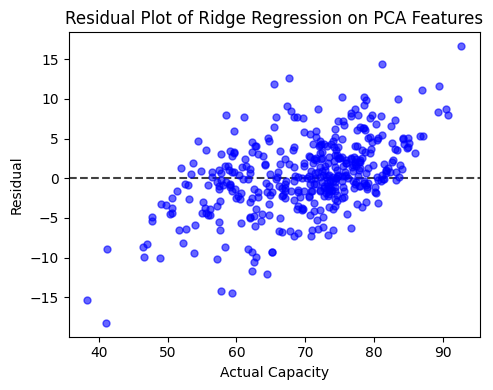

In [22]:
test_pred = linear_model.predict(X_test_N)

test_mae = mean_absolute_error(y_test['TARGET_Capacity'], test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test['TARGET_Capacity'], test_pred))
test_r2 = r2_score(y_test['TARGET_Capacity'], test_pred)

print("--- Linear Regression Using All Features ---")
print(f"Mean Absolute Error (MAE): {test_mae:.2f}")
print(f'Testing data prediction (RMSE): {test_rmse:.2f}')
print(f'R-squared (R2): {test_r2:.2f}')

# Residual plot
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(y_test['TARGET_Capacity'], y_test['TARGET_Capacity'] - test_pred, s=25, color='blue', alpha=0.6, zorder=10)
xlims = ax.get_xlim()
ax.plot(xlims, [0.0,]*2, 'k--', alpha=0.75, zorder=0)
ax.set_xlim(xlims)
plt.title('Residual Plot of Ridge Regression on PCA Features')
plt.xlabel('Actual Capacity')
plt.ylabel('Residual')
plt.tight_layout()
plt.show()

> <span style="font-size:1em;">✔</span> **Observations:** 
* The residual plot shows a positive trending pattern rather than a random scatter around the y = 0 line, suggesting that the linear model may not fully capture the underlying patterns in the dataset.

### Poisson regression


--- Poisson regression Using All Features ---
Mean Absolute Error (MAE): 3.82
Training data prediction (RMSE): 4.64
Validation data prediction (RMSE): 4.93
Generalization Gap: 6.08%
R-squared (R2): 0.72
--- Poisson regression Using PCA Features (n_components=0.95) ---
Mean Absolute Error (MAE): 3.83
Training data prediction (RMSE): 4.66
Validation data prediction (RMSE): 4.94
Generalization Gap: 6.01%
R-squared (R2): 0.71


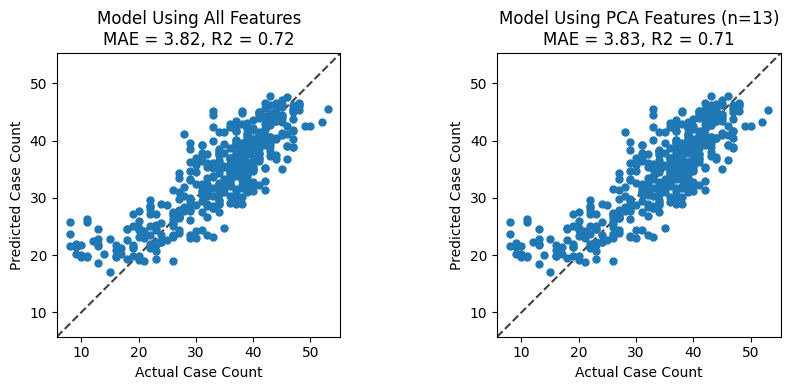

In [23]:
from sklearn.linear_model import PoissonRegressor

# Apply Poisson regression for 'TARGET_CaseCount' on all features
poisson_model = PoissonRegressor().fit(X_train_N, y_train['TARGET_CaseCount'])
y_train_N_pred = poisson_model.predict(X_train_N)
y_val_N_pred = poisson_model.predict(X_val_N)

val_N_mae = mean_absolute_error(y_val['TARGET_CaseCount'], y_val_N_pred)
train_N_rmse = np.sqrt(mean_squared_error(y_train['TARGET_CaseCount'], y_train_N_pred))
val_N_rmse = np.sqrt(mean_squared_error(y_val['TARGET_CaseCount'], y_val_N_pred))
val_N_r2 = r2_score(y_val['TARGET_CaseCount'], y_val_N_pred)

print("--- Poisson regression Using All Features ---")
print(f"Mean Absolute Error (MAE): {val_N_mae:.2f}")
print(f'Training data prediction (RMSE): {train_N_rmse:.2f}')
print(f'Validation data prediction (RMSE): {val_N_rmse:.2f}')
print(f'Generalization Gap: {abs(val_N_rmse - train_N_rmse)*100/train_N_rmse:.2f}%')
print(f'R-squared (R2): {val_N_r2:.2f}')


# Apply Poisson regression for 'TARGET_CaseCount' on PCA features
poisson_PCA_model = PoissonRegressor().fit(X_train_PCA, y_train['TARGET_CaseCount'])
y_train_PCA_pred = poisson_PCA_model.predict(X_train_PCA)
y_val_PCA_pred = poisson_PCA_model.predict(X_val_PCA)

val_PCA_mae = mean_absolute_error(y_val['TARGET_CaseCount'], y_val_PCA_pred)
train_PCA_rmse = np.sqrt(mean_squared_error(y_train['TARGET_CaseCount'], y_train_PCA_pred))
val_PCA_rmse = np.sqrt(mean_squared_error(y_val['TARGET_CaseCount'], y_val_PCA_pred))
val_PCA_r2 = r2_score(y_val['TARGET_CaseCount'], y_val_PCA_pred)

print("--- Poisson regression Using PCA Features (n_components=0.95) ---")
print(f"Mean Absolute Error (MAE): {val_PCA_mae:.2f}")
print(f'Training data prediction (RMSE): {train_PCA_rmse:.2f}')
print(f'Validation data prediction (RMSE): {val_PCA_rmse:.2f}')
print(f'Generalization Gap: {abs(val_PCA_rmse - train_PCA_rmse)*100/train_PCA_rmse:.2f}%')
print(f'R-squared (R2): {val_PCA_r2:.2f}')


fig, axes = plt.subplots(1, 2, figsize=(9, 4))
titles = ["Model Using All Features", "Model Using PCA Features (n=13)"]
predictions = [y_val_N_pred, y_val_PCA_pred]
metrics = [(val_N_mae, val_N_r2), (val_PCA_mae, val_PCA_r2)]

for ax, title, pred, (rmse, r2) in zip(axes, titles, predictions, metrics):
    ax.scatter(y_val['TARGET_CaseCount'], pred, s=25, zorder=10)
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]), 
        np.max([ax.get_xlim(), ax.get_ylim()]), 
    ]
    ax.plot(lims, lims, 'k--', alpha=0.75, zorder=0)
    ax.set_aspect('equal')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_title(f"{title}\nMAE = {round(rmse, 2)}, R2 = {round(r2, 2)}")
    ax.set_xlabel('Actual Case Count')
    ax.set_ylabel('Predicted Case Count')

plt.tight_layout()
plt.show()


> <span style="font-size:1em;">✔</span> **Observations:**
* Both of the Poisson regression models, with and without PCA, perform very similarly across all metrics. The model using all features is only slightly performing better than the model trained with PCA features.

### Parameter tuning - PCA components
The following parameter tuning will explore the performance of using different numbers of PCA components to train the Poisson regression model, aiming to find the optimal component count based on the R2 score.

When n_components = 21 train model has highest R^2: 0.7154228445585229


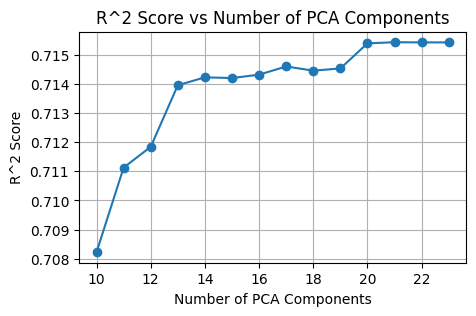

In [24]:
from sklearn.linear_model import PoissonRegressor

r2_scores = []
n_components_range = range(10, 24)

for n in n_components_range:
    # Apply PCA
    pca = PCA(n_components=n)
    train_PCA = pca.fit_transform(X_train_N)
    val_PCA = pca.transform(X_val_N)
    train_PCA = pd.DataFrame(train_PCA, index=X_train_N.index)
    val_PCA = pd.DataFrame(val_PCA, index=X_val_N.index)
    
    # Train Linear Poisson Model
    pn_model = PoissonRegressor().fit(train_PCA, y_train['TARGET_CaseCount'])
    val_PCA_pred = pn_model.predict(val_PCA)
    
    # Compute R^2 score
    r2 = r2_score(y_val['TARGET_CaseCount'], val_PCA_pred)
    r2_scores.append(r2)

best_index = np.argmax(r2_scores)
print(f'When n_components = {n_components_range[best_index]} train model has highest R^2: {r2_scores[best_index]}')

plt.figure(figsize=(5, 3))
plt.plot(n_components_range, r2_scores, marker='o', linestyle='-')
plt.xlabel('Number of PCA Components')
plt.ylabel('R^2 Score')
plt.title('R^2 Score vs Number of PCA Components')
plt.grid()
plt.show()

> <span style="font-size:1em;">✔</span> **Observations:**
* The grid serch for optimal PCA component show that when using 21 PCA components will have a highest R2 at 0.72, which does not improve the baseline or model complexity much. Therefore, PCA is not suitable for applying in this model.
* We then plot the coefficients of the linear model and choose a suitable regularisation technuque to further improve the model.

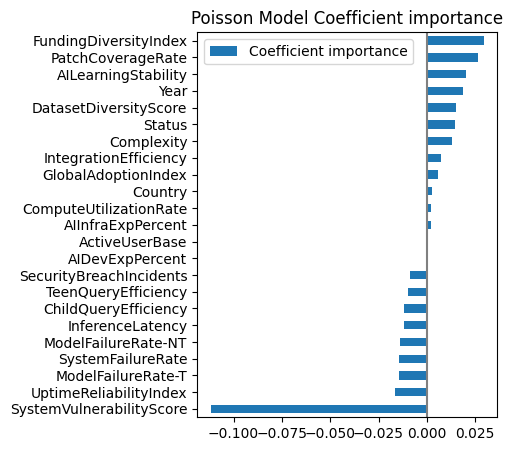

In [25]:
# Feature importance

coefs = pd.DataFrame(
    poisson_model.coef_  * X_train_N.std(axis=0),
    columns=['Coefficient importance'], 
    index=X_train_N.columns
)
coefs.sort_values(by=['Coefficient importance']).plot(kind='barh', figsize=(5, 5))
plt.title('Poisson Model Coefficient importance')
plt.axvline(x=0, color='.5')
plt.subplots_adjust(left=.3)
plt.show()

### Parameter tuning - Regularization
Based on the coefficient importance plot, there is a highly influential feature `SystemVulnerabilityScore` that may dominate the model and lead to overfitting. Therefore, Ridge regression will be used to create a more balanced model and improve generalization.

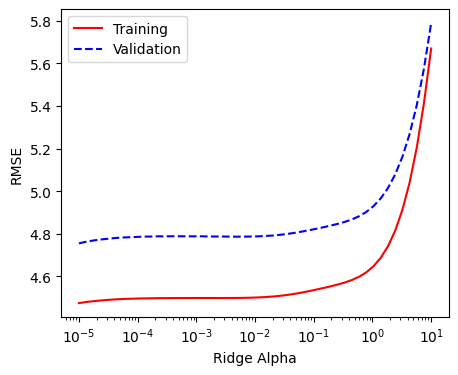

In [27]:
# Poisson + Regularization
alphas = np.logspace(-5, 1)
train_errors = []
val_errors = []

for alpha in alphas:
    poisson_model_reg_l2 = PoissonRegressor(alpha=alpha,max_iter=10000 )
    poisson_model_reg_l2.fit(X_train_N , y_train['TARGET_CaseCount'])
    
    train_pred = poisson_model_reg_l2.predict(X_train_N)
    val_pred = poisson_model_reg_l2.predict(X_val_N)
    
    train_errors.append(np.sqrt(mean_squared_error(y_train['TARGET_CaseCount'], train_pred)))
    val_errors.append(np.sqrt(mean_squared_error(y_val['TARGET_CaseCount'], val_pred)))
    
plt.figure(figsize=(5, 4))
plt.plot([alpha for alpha in alphas],[tp for tp in train_errors], 'r-')
plt.plot([alpha for alpha in alphas],[vp for vp in val_errors], 'b--')
plt.xscale("log")
plt.ylabel('RMSE')
plt.xlabel('Ridge Alpha')
plt.legend(['Training','Validation'])
plt.show()

In [28]:
# Apply Ridge regularization with selected best alpha on all features

poisson_model_reg_l2 = PoissonRegressor(alpha=0.1)
poisson_model_reg_l2.fit(X_train_N , y_train['TARGET_CaseCount'])

train_ridge_pred = poisson_model_reg_l2.predict(X_train_N)
val_ridge_pred = poisson_model_reg_l2.predict(X_val_N)

val_ridge_mae = mean_absolute_error(y_val['TARGET_CaseCount'], val_ridge_pred)
train_ridge_rmse = np.sqrt(mean_squared_error(y_train['TARGET_CaseCount'], train_ridge_pred))
val_ridge_rmse = np.sqrt(mean_squared_error(y_val['TARGET_CaseCount'], val_ridge_pred))
val_ridge_r2 = r2_score(y_val['TARGET_CaseCount'], val_ridge_pred)

print("--- Poisson Regression Using all features and Ridge regularization ---")
print(f"Mean Absolute Error (MAE): {val_ridge_mae:.2f}")
print(f'Training data prediction (RMSE): {train_ridge_rmse:.2f}')
print(f'Validation data prediction (RMSE): {val_ridge_rmse:.2f}')
print(f'Generalization Gap: {abs(val_ridge_rmse - train_ridge_rmse)*100/train_ridge_rmse:.2f}%')
print(f'R-squared (R2): {val_ridge_r2:.2f}')

--- Poisson Regression Using all features and Ridge regularization ---
Mean Absolute Error (MAE): 3.77
Training data prediction (RMSE): 4.54
Validation data prediction (RMSE): 4.82
Generalization Gap: 6.30%
R-squared (R2): 0.73


> <span style="font-size:1em;">✔</span> **Observations:** 
* The graph shows that as the Ridge alpha approaches 0, the RMSE decreases, indicating that applying Ridge regularisation may not improve the model's performance and the model performs better with minimal or no penalisation. 
* As shown above, even when using a small alpha value for regularization, the R2 score only improved slightly ( 0.72 -> 0.73). Therefore, we consider regularization unnecessary in this case and proceed with the model trained using all features, applying it to the testing data.

--- Poisson Regression Using All Features ---
Mean Absolute Error (MAE): 3.84
Testing data prediction (RMSE): 5.03
R-squared (R2): 0.72


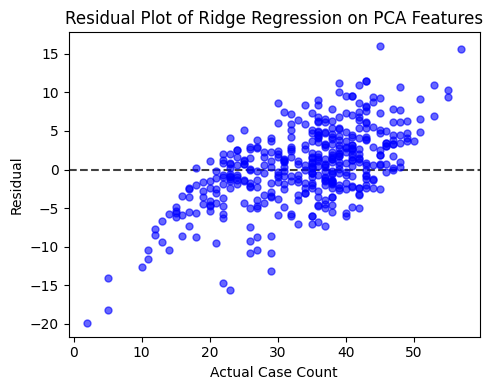

In [29]:
# Evaluate optimal trained model on testing dataset
test_pred = poisson_model.predict(X_test_N)


test_mae = mean_absolute_error(y_test['TARGET_CaseCount'], test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test['TARGET_CaseCount'], test_pred))
test_r2 = r2_score(y_test['TARGET_CaseCount'], test_pred)

print("--- Poisson Regression Using All Features ---")
print(f"Mean Absolute Error (MAE): {test_mae:.2f}")
print(f'Testing data prediction (RMSE): {test_rmse:.2f}')
print(f'R-squared (R2): {test_r2:.2f}')

# Residual plot
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(y_test['TARGET_CaseCount'], y_test['TARGET_CaseCount'] - test_pred, s=25, color='blue', alpha=0.6, zorder=10)
xlims = ax.get_xlim()
ax.plot(xlims, [0.0,]*2, 'k--', alpha=0.75, zorder=0)
ax.set_xlim(xlims)
plt.title('Residual Plot of Ridge Regression on PCA Features')
plt.xlabel('Actual Case Count')
plt.ylabel('Residual')
plt.tight_layout()
plt.show()

> <span style="font-size:1em;">✔</span> **Observations:** 
* The residual plot shows a positive trending pattern rather than a random scatter around the y = 0 line, suggesting that the linear model may not fully capture the underlying patterns in the dataset.

## 4. Polynomial regression regression only for TARGET_Capacity prediction

* A polynomial model trained with a 2nd-degree transformation on all features will be compared to one trained with PCA features that capture 95% of the variance.

* A 2nd-degree transformation of 23 features will results in having 300 features. Therefore, performance of different numbers of PCA components will also be evaluated for feature reduction.

* Regularization will also be applied and tuned to reduce overfitting and model complexity.

* To avoid being too sensitive to outliers, MAE will be primarily used to compare prediction error. RMSE will be used to calculate the generalization gap and detect potential overfitting. R2 will also be used to evaluate overall model performance in terms of how well it fits the data.

In [30]:
from sklearn.preprocessing import PolynomialFeatures

# Apply polynomial feature transformation (degree = 2)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_N)
X_val_poly = poly.transform(X_val_N)
X_test_poly = poly.transform(X_test_N)
print(f"Number of features after polynomial transform: {X_train_poly.shape[1]}")

# Scale the polynomial features using MinMaxScaler
scaler_poly = MinMaxScaler()
X_train_poly_scaled = scaler_poly.fit_transform(X_train_poly)
X_val_poly_scaled = scaler_poly.transform(X_val_poly)
X_test_poly_scaled = scaler_poly.transform(X_test_poly)
# Convert back to DataFrame and restore index
X_train_poly_scaled = pd.DataFrame(X_train_poly_scaled, index=X_train_N.index, columns=poly.get_feature_names_out(X_train_N.columns))
X_val_poly_scaled = pd.DataFrame(X_val_poly_scaled, index=X_val_N.index, columns=poly.get_feature_names_out(X_val_N.columns))
X_test_poly_scaled = pd.DataFrame(X_test_poly_scaled, index=X_test_N.index, columns=poly.get_feature_names_out(X_test_N.columns))


# Apply linear regression
lr_poly_model = LinearRegression()
lr_poly_model.fit(X_train_poly_scaled, y_train['TARGET_Capacity'])
y_train_poly_pred = lr_poly_model.predict(X_train_poly_scaled)
y_val_poly_pred = lr_poly_model.predict(X_val_poly_scaled)

val_poly_mae = mean_absolute_error(y_val['TARGET_Capacity'], y_val_poly_pred)
train_poly_rmse = np.sqrt(mean_squared_error(y_train['TARGET_Capacity'], y_train_poly_pred))
val_poly_rmse = np.sqrt(mean_squared_error(y_val['TARGET_Capacity'], y_val_poly_pred))
val_poly_r2 = r2_score(y_val['TARGET_Capacity'], y_val_poly_pred)

print("--- Polynomial Linear Regression (Degree 2) Using All Features ---")
print(f"Mean Absolute Error (MAE): {val_poly_mae:.2f}")
print(f'Training data prediction (RMSE): {train_poly_rmse:.2f}')
print(f'Validation data prediction (RMSE): {val_poly_rmse:.2f}')
print(f'Generalization Gap: {abs(val_poly_rmse - train_poly_rmse)*100/train_poly_rmse:.2f}%')
print(f'R-squared (R2): {val_poly_r2:.2f}')


# Use PCA features for polynomial linear regression
pca = PCA(n_components=0.95)
X_train_PCA = pca.fit_transform(X_train_poly_scaled)
X_val_PCA = pca.transform(X_val_poly_scaled) 
X_test_PCA = pca.transform(X_test_poly_scaled)
X_train_PCA = pd.DataFrame(X_train_PCA, index=X_train_N.index, columns=[f'PC{i+1}' for i in range(X_train_PCA.shape[1])])
X_val_PCA = pd.DataFrame(X_val_PCA, index=X_val_N.index, columns=[f'PC{i+1}' for i in range(X_val_PCA.shape[1])])
X_test_PCA = pd.DataFrame(X_test_PCA, index=X_test_N.index, columns=[f'PC{i+1}' for i in range(X_test_PCA.shape[1])])

lr_poly_PCA_model = LinearRegression()
lr_poly_PCA_model.fit(X_train_PCA, y_train['TARGET_Capacity'])
y_train_poly_PCA_pred = lr_poly_PCA_model.predict(X_train_PCA)
y_val_poly_PCA_pred = lr_poly_PCA_model.predict(X_val_PCA)

val_poly_PCA_mae = mean_absolute_error(y_val['TARGET_Capacity'], y_val_poly_PCA_pred)
train_poly_PCA_rmse = np.sqrt(mean_squared_error(y_train['TARGET_Capacity'], y_train_poly_pred))
val_poly_PCA_rmse = np.sqrt(mean_squared_error(y_val['TARGET_Capacity'], y_val_poly_PCA_pred))
val_poly_PCA_r2 = r2_score(y_val['TARGET_Capacity'], y_val_poly_PCA_pred)

print("--- Polynomial Linear Regression (Degree 2) Using PCA Features ---")
print(f"Number of PCA components: {pca.n_components_}")
print(f"Mean Absolute Error (MAE): {val_poly_PCA_mae:.2f}")
print(f'Training data prediction (RMSE): {train_poly_PCA_rmse:.2f}')
print(f'Validation data prediction (RMSE): {val_poly_PCA_rmse:.2f}')
print(f'Generalization Gap: {abs(val_poly_PCA_rmse - train_poly_PCA_rmse)*100/train_poly_PCA_rmse:.2f}%')
print(f'R-squared (R2): {val_poly_PCA_r2:.2f}')



Number of features after polynomial transform: 300
--- Polynomial Linear Regression (Degree 2) Using All Features ---
Mean Absolute Error (MAE): 2.85
Training data prediction (RMSE): 2.59
Validation data prediction (RMSE): 3.68
Generalization Gap: 42.22%
R-squared (R2): 0.84
--- Polynomial Linear Regression (Degree 2) Using PCA Features ---
Number of PCA components: 25
Mean Absolute Error (MAE): 3.45
Training data prediction (RMSE): 2.59
Validation data prediction (RMSE): 4.48
Generalization Gap: 73.24%
R-squared (R2): 0.76


> <span style="font-size:1em;">✔</span> **Observations:**
The Polynomial Linear Regression model using all features performed better than the model using PCA. It achieved a lower MAE (2.85 vs. 3.45),lower RMSE (3.68 vs. 4.48), and a higher R2 score (0.84 vs. 0.76). Both models showed high generalization gap (42.22% vs. 73.24%), indicating that the models were overfitting. Therefore, futher parameter tuning and regularization will be needed to reduce complexity of the model.

### Parameter tuning - PCA components
The following parameter tuning will explore the performance of using different numbers of PCA components to train the Polynomial Linear Regression model, aiming to find the optimal component count based on the R2 score.

When n_components = 170 train model has highest R2: 0.86


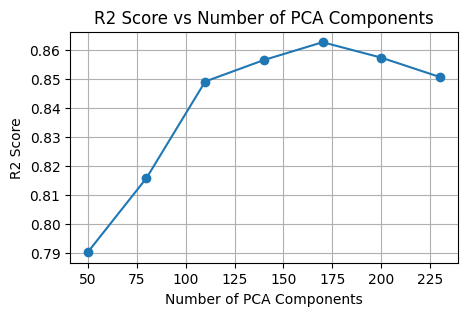

In [31]:
r2_scores = []
n_components_range = range(50, 250,30)

for n in n_components_range:
    pca = PCA(n_components=n)
    train_PCA = pca.fit_transform(X_train_poly_scaled)
    val_PCA = pca.transform(X_val_poly_scaled)
    train_PCA = pd.DataFrame(train_PCA, index=X_train_poly_scaled.index)
    val_PCA = pd.DataFrame(val_PCA, index=X_val_poly_scaled.index)
    
    lr_model = LinearRegression().fit(train_PCA, y_train['TARGET_Capacity'])
    val_PCA_pred = lr_model.predict(val_PCA)
    
    r2 = r2_score(y_val['TARGET_Capacity'], val_PCA_pred)
    r2_scores.append(r2)

best_index = np.argmax(r2_scores)
print(f'When n_components = {n_components_range[best_index]} train model has highest R2: {r2_scores[best_index]:.2f}')

plt.figure(figsize=(5, 3))
plt.plot(n_components_range, r2_scores, marker='o', linestyle='-')
plt.xlabel('Number of PCA Components')
plt.ylabel('R2 Score')
plt.title('R2 Score vs Number of PCA Components')
plt.grid()
plt.show()

In [32]:
# Use optimal number os PCA features for polynomial 
pca = PCA(n_components=170)
X_train_PCA = pca.fit_transform(X_train_poly_scaled)
X_val_PCA = pca.transform(X_val_poly_scaled) 
X_test_PCA = pca.transform(X_test_poly_scaled)
X_train_PCA = pd.DataFrame(X_train_PCA, index=X_train_N.index, columns=[f'PC{i+1}' for i in range(X_train_PCA.shape[1])])
X_val_PCA = pd.DataFrame(X_val_PCA, index=X_val_N.index, columns=[f'PC{i+1}' for i in range(X_val_PCA.shape[1])])
X_test_PCA = pd.DataFrame(X_test_PCA, index=X_test_N.index, columns=[f'PC{i+1}' for i in range(X_test_PCA.shape[1])])

lr_poly_PCA_model = LinearRegression()
lr_poly_PCA_model.fit(X_train_PCA, y_train['TARGET_Capacity'])
y_train_poly_PCA_pred = lr_poly_PCA_model.predict(X_train_PCA)
y_val_poly_PCA_pred = lr_poly_PCA_model.predict(X_val_PCA)

val_poly_PCA_mae = mean_absolute_error(y_val['TARGET_Capacity'], y_val_poly_PCA_pred)
train_poly_PCA_rmse = np.sqrt(mean_squared_error(y_train['TARGET_Capacity'], y_train_poly_pred))
val_poly_PCA_rmse = np.sqrt(mean_squared_error(y_val['TARGET_Capacity'], y_val_poly_PCA_pred))
val_poly_PCA_r2 = r2_score(y_val['TARGET_Capacity'], y_val_poly_PCA_pred)

print("--- Polynomial Linear Regression (Degree 2) Using PCA Features ---")
print(f"Number of PCA components: {pca.n_components_}")
print(f"Mean Absolute Error (MAE): {val_poly_PCA_mae:.2f}")
print(f'Training data prediction (RMSE): {train_poly_PCA_rmse:.2f}')
print(f'Validation data prediction (RMSE): {val_poly_PCA_rmse:.2f}')
print(f'Generalization Gap: {abs(val_poly_PCA_rmse - train_poly_PCA_rmse)*100/train_poly_PCA_rmse:.2f}%')
print(f'R-squared (R2): {val_poly_PCA_r2:.2f}')

--- Polynomial Linear Regression (Degree 2) Using PCA Features ---
Number of PCA components: 170
Mean Absolute Error (MAE): 2.61
Training data prediction (RMSE): 2.59
Validation data prediction (RMSE): 3.43
Generalization Gap: 32.48%
R-squared (R2): 0.86


> <span style="font-size:1em;">✔</span> **Observations:**

Using grid search to find the optimal component count for PCA greatly improved the R2 score (0.76 -> 0.86) and the generalization gap (73.24% -> 32.63%), but we are aiming for a generalization gap below 20%. Therefore, Ridge regularisation will be applied to the PCA features to further reduce the overfitting of the model.

### Parameter tuning - Regularization
The following parameter tuning will explore the performance of using different alpha values to train the Polynomial Linear Regression model using PCA features with Ridge regularisation, aiming to find the optimal alpha that minimizes the generalization gap.

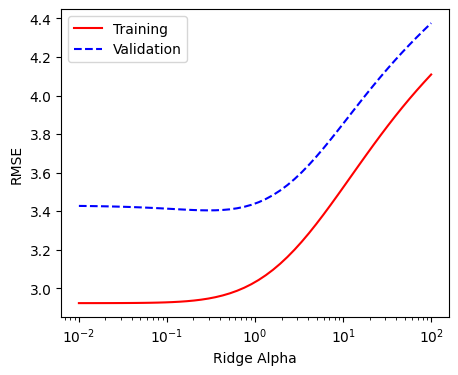

In [33]:
from sklearn.linear_model import Ridge

alphas = np.logspace(-2, 2)
train_errors = []
val_errors = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_PCA , y_train['TARGET_Capacity'])
    
    train_pred = ridge.predict(X_train_PCA)
    val_pred = ridge.predict(X_val_PCA)
    
    train_errors.append(np.sqrt(mean_squared_error(y_train['TARGET_Capacity'], train_pred)))
    val_errors.append(np.sqrt(mean_squared_error(y_val['TARGET_Capacity'], val_pred)))
    
plt.figure(figsize=(5, 4))
plt.plot([alpha for alpha in alphas],[tp for tp in train_errors], 'r-')
plt.plot([alpha for alpha in alphas],[vp for vp in val_errors], 'b--')
plt.xscale("log")
plt.ylabel('RMSE')
plt.xlabel('Ridge Alpha')
plt.legend(['Training','Validation'])
plt.show()

In [34]:
# Apply Ridge regularization with selected best alpha on PCA features
poly_ridge_model = Ridge(alpha=1).fit(X_train_PCA , y_train['TARGET_Capacity'])
train_ridge_pred = poly_ridge_model.predict(X_train_PCA)
val_ridge_pred = poly_ridge_model.predict(X_val_PCA)

val_ridge_mae = mean_absolute_error(y_val['TARGET_Capacity'], val_ridge_pred)
train_ridge_rmse = np.sqrt(mean_squared_error(y_train['TARGET_Capacity'], train_ridge_pred))
val_ridge_rmse = np.sqrt(mean_squared_error(y_val['TARGET_Capacity'], val_ridge_pred))
val_ridge_r2 = r2_score(y_val['TARGET_Capacity'], val_ridge_pred)

print("--- Polynomial Linear Regression (Degree 2) Using PCA Features and Ridge regularization ---")
print(f"Number of PCA components: {pca.n_components_}")
print(f"Mean Absolute Error (MAE): {val_ridge_mae:.2f}")
print(f'Training data prediction (RMSE): {train_ridge_rmse:.2f}')
print(f'Validation data prediction (RMSE): {val_ridge_rmse:.2f}')
print(f'Generalization Gap: {abs(val_ridge_rmse - train_ridge_rmse)*100/train_ridge_rmse:.2f}%')
print(f'R-squared (R2): {val_ridge_r2:.2f}')

--- Polynomial Linear Regression (Degree 2) Using PCA Features and Ridge regularization ---
Number of PCA components: 170
Mean Absolute Error (MAE): 2.61
Training data prediction (RMSE): 3.03
Validation data prediction (RMSE): 3.44
Generalization Gap: 13.45%
R-squared (R2): 0.86


> <span style="font-size:1em;">✔</span> **Observations:** 
* The graph shows that when Ridge alpha = 1, the validation prediction RMSE is close to its lowest point, with only a small gap between the training and validation RMSE.

* The performance metrics indicate that using the optimal alpha significantly reduced the generalisation gap (from 32.34% to 13.41%).

* Since Ridge regression does not eliminate any features, the feature count remains at 170, which is slightly high. Therefore, Lasso regularisation will be explored further to reduce model complexity and mitigate overfitting.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.793e+01, tolerance: 1.133e+01
  model = cd_fast.enet_coordinate_descent(


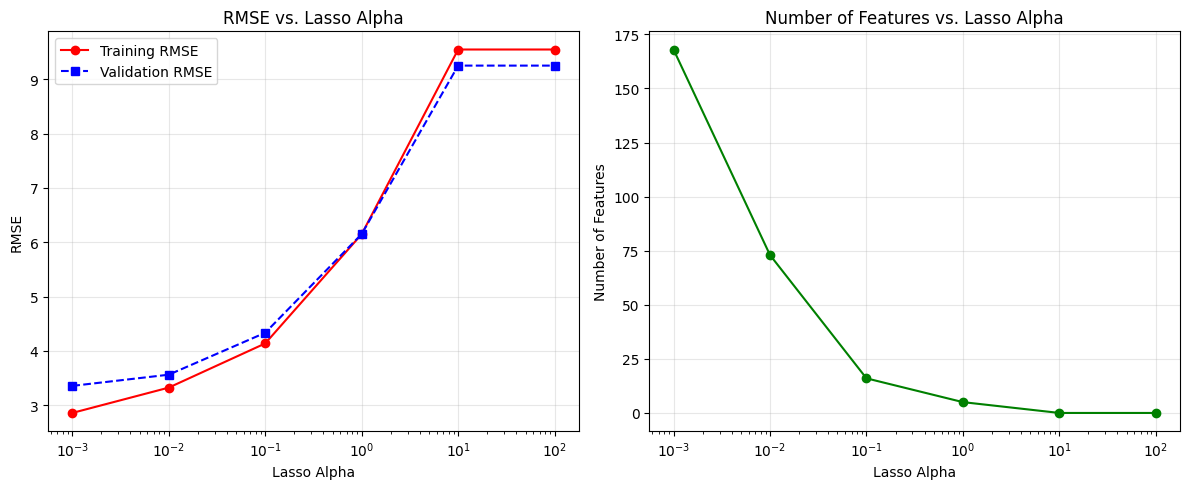

In [35]:
from sklearn.linear_model import Lasso

alphas = [0.001, 0.01, 0.1, 1, 10, 100]
# alphas = np.logspace(-2, 2)
train_errors = []
val_errors = []
num_features = []

for alpha in alphas:

    lasso = Lasso(alpha=alpha, max_iter=10000)
    # lasso.fit(X_train_PCA, y_train['TARGET_Capacity'])
    lasso.fit(X_train_poly_scaled, y_train['TARGET_Capacity'])
    
    # train_pred = lasso.predict(X_train_PCA)
    # val_pred = lasso.predict(X_val_PCA)
    train_pred = lasso.predict(X_train_poly_scaled)
    val_pred = lasso.predict(X_val_poly_scaled)
    
    train_rmse = np.sqrt(mean_squared_error(y_train['TARGET_Capacity'], train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val['TARGET_Capacity'], val_pred))
    n_features = np.sum(lasso.coef_ != 0) # Non-zero coefficients count
    
    train_errors.append(train_rmse)
    val_errors.append(val_rmse)
    num_features.append(n_features)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot the RMSE for training and validation sets
ax1.plot(alphas, train_errors, 'r-', marker='o', label='Training RMSE')
ax1.plot(alphas, val_errors, 'b--', marker='s', label='Validation RMSE')
ax1.set_xscale("log") 
ax1.set_title('RMSE vs. Lasso Alpha')
ax1.set_xlabel('Lasso Alpha')
ax1.set_ylabel('RMSE')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot the number of features selected at each alpha
ax2.plot(alphas, num_features, 'g-', marker='o')
ax2.set_xscale("log")
ax2.set_title('Number of Features vs. Lasso Alpha')
ax2.set_xlabel('Lasso Alpha')
ax2.set_ylabel('Number of Features')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [36]:
# Apply Lasso with optimal alpha on all features
lasso_model = Lasso(alpha=0.01, max_iter=10000).fit(X_train_poly_scaled, y_train['TARGET_Capacity'])

train_lasso_pred = lasso_model.predict(X_train_poly_scaled)
val_lasso_pred = lasso_model.predict(X_val_poly_scaled)

val_lasso_mae = mean_absolute_error(y_val['TARGET_Capacity'], val_lasso_pred)
train_lasso_rmse = np.sqrt(mean_squared_error(y_train['TARGET_Capacity'], train_lasso_pred))
val_lasso_rmse = np.sqrt(mean_squared_error(y_val['TARGET_Capacity'], val_lasso_pred))
val_lasso_r2 = r2_score(y_val['TARGET_Capacity'], val_lasso_pred)

print("--- Polynomial Linear Regression (Degree 2) Using Lasso Regularization ---")
print(f"Features used after Lasso: {np.sum(lasso.coef_ != 0)}")
print(f"Mean Absolute Error (MAE): {val_lasso_mae:.2f}")
print(f'Training data prediction (RMSE): {train_lasso_rmse:.2f}')
print(f'Validation data prediction (RMSE): {val_lasso_rmse:.2f}')
print(f'Generalization Gap: {abs(val_lasso_rmse - train_lasso_rmse)*100/train_lasso_rmse:.2f}%')
print(f'R-squared (R2): {val_lasso_r2:.2f}')


--- Polynomial Linear Regression (Degree 2) Using Lasso Regularization ---
Features used after Lasso: 0
Mean Absolute Error (MAE): 2.75
Training data prediction (RMSE): 3.32
Validation data prediction (RMSE): 3.56
Generalization Gap: 7.16%
R-squared (R2): 0.85


> <span style="font-size:1em;">✔</span> **Observations:** 
* The graph shows that when Lasso alpha = 0.01, the validation prediction RMSE is close to its lowest point, with a small gap between the training and validation RMSE. 

* Additionally, the number of features is around 75, which is much lower than the original 300 features.

### Evaluate optimized trained model
Based on the above metrics, the polynomial regression model using Lasso regularisation is a better choice for final evaluation on the testing data. It shows stronger generalisation with a lower gap between training and validation performance (7.16% vs. 13.41%), while still achieving low MAE and RMSE values. Additionally, the model complexity is much lower (73 features vs. 170 PCA components) and is easier to interpret, which indicates more stable and reliable performance.

--- Polynomial Linear Regression (Degree 2) Using Lasso Regularization ---
Features used after Lasso: 73
Mean Absolute Error (MAE): 2.81
Testing data prediction (RMSE): 1.68
R-squared (R2): 0.84


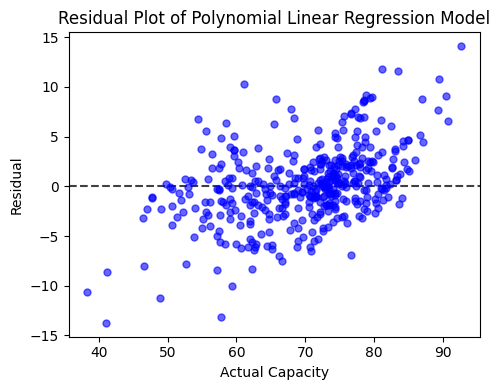

In [37]:
# Evaluate optimized trained model on test dataset
print("--- Polynomial Linear Regression (Degree 2) Using Lasso Regularization ---")
test_poly_pred = lasso_model.predict(X_test_poly_scaled)
test_poly_mae = mean_absolute_error(y_test['TARGET_Capacity'], test_poly_pred)
test_poly_rmse = np.sqrt(mean_absolute_error(y_test['TARGET_Capacity'], test_poly_pred))
test_poly_r2 = r2_score(y_test['TARGET_Capacity'], test_poly_pred)
print(f"Features used after Lasso: {np.sum(lasso_model.coef_ != 0)}")
print(f"Mean Absolute Error (MAE): {test_poly_mae:.2f}")
print(f'Testing data prediction (RMSE): {test_poly_rmse:.2f}')
print(f'R-squared (R2): {test_poly_r2:.2f}')

# Residual plot
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(y_test['TARGET_Capacity'], y_test['TARGET_Capacity'] - test_poly_pred, s=25, color='blue', alpha=0.6, zorder=10)
xlims = ax.get_xlim()
ax.plot(xlims, [0.0,]*2, 'k--', alpha=0.75, zorder=0)
ax.set_xlim(xlims)
plt.title('Residual Plot of Polynomial Linear Regression Model')
plt.xlabel('Actual Capacity')
plt.ylabel('Residual')
plt.tight_layout()
plt.show()

> <span style="font-size:1em;">✔</span> **Observations:** 
* The testing results for Polynomial Regression with Lasso showed performance consistent with the training and validation metrics, with an R2 of 0.84 and low MAE and RMSE, indicating that the model predicts well on unseen data.
* The Polynomial Linear Regressio model residual plot slightly improved the possitive trending pattern in the residuals compared to the baseline.

## 5. Single Linear or Polynomial regression with two outputs

Based on the EDA of the dataset, `Target_Capacity` and `Target_CaseCount` have a correlation of 1, indicating a perfect linear relationship, they can be expressed as y = ax + b. Therefore, we only need to optimize one of the target prediction models, as the other target value can be calculated from it.

* Modeling Approach:
Based on the training model performance above, the polynomial regression model using Lasso regularization shows the best performance for predicting Target_Capacity. Therefore, this model will be used to first predict Target_Capacity, and its prediction will then be used to predict the other highly correlated target, Target_CaseCount, in combination using a regressor chain.

* To avoid being too sensitive to outliers, MAE will be primarily used to evaluate the accuracy. RMSE will be used to calculate the generalization gap and detect potential overfitting. R2 will also be used to evaluate overall model performance in terms of how well it fits the data.

In [38]:
from sklearn.multioutput import RegressorChain

# Use previously trained polynomial regression model using Lasso regularization
capacity_model = lasso_model
chain_model = RegressorChain(capacity_model, order=[0, 1])  # 0 = Capacity, 1 = CaseCount
chain_model.fit(X_train_poly_scaled, y_train)
y_train_pred = chain_model.predict(X_train_poly_scaled)
y_val_pred = chain_model.predict(X_val_poly_scaled)

y_train_pred = pd.DataFrame(y_train_pred, index=y_train.index, columns=y_train.columns)
y_val_pred = pd.DataFrame(y_val_pred, index=y_val.index, columns=y_val.columns)

# TARGET_Capacity Prediction Performance
train_capacity_rmse = np.sqrt(mean_squared_error(y_train['TARGET_Capacity'], y_train_pred['TARGET_Capacity']))
val_capacity_rmse = np.sqrt(mean_squared_error(y_val['TARGET_Capacity'], y_val_pred['TARGET_Capacity']))
val_capacity_mae = mean_absolute_error(y_val['TARGET_Capacity'], y_val_pred['TARGET_Capacity'])
val_capacity_r2 = r2_score(y_val['TARGET_Capacity'], y_val_pred['TARGET_Capacity'])
capacity_generalization_gap = abs(val_capacity_rmse - train_capacity_rmse) * 100 / train_capacity_rmse
print("--- TARGET_Capacity Prediction Performance ---")
print(f"Mean Absolute Error (MAE): {val_capacity_mae:.2f}")
print(f"Training data prediction (RMSE): {train_capacity_rmse:.2f}")
print(f"Validation data prediction (RMSE): {val_capacity_rmse:.2f}")
print(f"Generalization Gap: {capacity_generalization_gap:.2f}%")
print(f"R-squared (R2): {val_capacity_r2:.2f}")

# TARGET_CaseCount prediction performance
train_casecount_rmse = np.sqrt(mean_squared_error(y_train['TARGET_CaseCount'], y_train_pred['TARGET_CaseCount']))
val_casecount_rmse = np.sqrt(mean_squared_error(y_val['TARGET_CaseCount'], y_val_pred['TARGET_CaseCount']))
val_casecount_mae = mean_absolute_error(y_val['TARGET_CaseCount'], y_val_pred['TARGET_CaseCount'])
val_casecount_r2 = r2_score(y_val['TARGET_CaseCount'], y_val_pred['TARGET_CaseCount'])
casecount_generalization_gap = abs(val_casecount_rmse - train_casecount_rmse) * 100 / train_casecount_rmse

print("--- TARGET_CaseCount Prediction Performance ---")
print(f"Mean Absolute Error (MAE): {val_casecount_mae:.2f}")
print(f"Training data prediction (RMSE): {train_casecount_rmse:.2f}")
print(f"Validation data prediction (RMSE): {val_casecount_rmse:.2f}")
print(f"Generalization Gap: {casecount_generalization_gap:.2f}%")
print(f"R-squared (R2): {val_casecount_r2:.2f}")

--- TARGET_Capacity Prediction Performance ---
Mean Absolute Error (MAE): 2.75
Training data prediction (RMSE): 3.32
Validation data prediction (RMSE): 3.56
Generalization Gap: 7.16%
R-squared (R2): 0.85
--- TARGET_CaseCount Prediction Performance ---
Mean Absolute Error (MAE): 2.75
Training data prediction (RMSE): 3.33
Validation data prediction (RMSE): 3.58
Generalization Gap: 7.62%
R-squared (R2): 0.85


--- TARGET_Capacity Prediction Performance ---
Mean Absolute Error (MAE): 2.81
Testing data prediction (RMSE): 3.83
R-squared (R2): 0.84
--- TARGET_CaseCount Prediction Performance ---
Mean Absolute Error (MAE): 2.83
Testing data prediction (RMSE): 3.84
R-squared (R2): 0.84


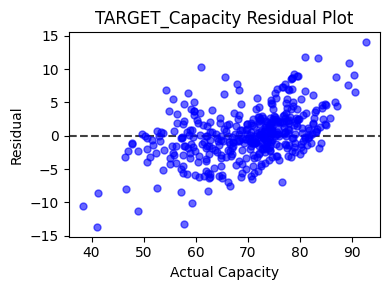

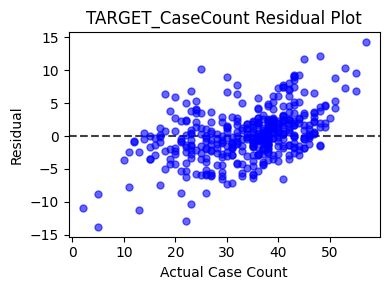

In [43]:
# Predict on testing dataset using the trained RegressorChain model
y_test_pred = chain_model.predict(X_test_poly_scaled)
y_test_pred = pd.DataFrame(y_test_pred, index=y_test.index, columns=y_test.columns)

# TARGET_Capacity Prediction Performance
test_capacity_mae = mean_absolute_error(y_test['TARGET_Capacity'], y_test_pred['TARGET_Capacity'])
test_capacity_rmse = np.sqrt(mean_squared_error(y_test['TARGET_Capacity'], y_test_pred['TARGET_Capacity']))
test_capacity_r2 = r2_score(y_test['TARGET_Capacity'], y_test_pred['TARGET_Capacity'])

print("--- TARGET_Capacity Prediction Performance ---")
print(f"Mean Absolute Error (MAE): {test_capacity_mae:.2f}")
print(f"Testing data prediction (RMSE): {test_capacity_rmse:.2f}")
print(f"R-squared (R2): {test_capacity_r2:.2f}")

# TARGET_CaseCount Prediction Performance
test_casecount_mae = mean_absolute_error(y_test['TARGET_CaseCount'], y_test_pred['TARGET_CaseCount'])
test_casecount_rmse = np.sqrt(mean_squared_error(y_test['TARGET_CaseCount'], y_test_pred['TARGET_CaseCount']))
test_casecount_r2 = r2_score(y_test['TARGET_CaseCount'], y_test_pred['TARGET_CaseCount'])

print("--- TARGET_CaseCount Prediction Performance ---")
print(f"Mean Absolute Error (MAE): {test_casecount_mae:.2f}")
print(f"Testing data prediction (RMSE): {test_casecount_rmse:.2f}")
print(f"R-squared (R2): {test_casecount_r2:.2f}")


# Residual Plot for TARGET_Capacity
fig, ax = plt.subplots(figsize=(4, 3))
ax.scatter(y_test['TARGET_Capacity'], y_test['TARGET_Capacity'] - y_test_pred['TARGET_Capacity'],
           s=25, color='blue', alpha=0.6, zorder=10)
xlims = ax.get_xlim()
ax.plot(xlims, [0.0, 0.0], 'k--', alpha=0.75, zorder=0)
ax.set_xlim(xlims)
plt.title('TARGET_Capacity Residual Plot')
plt.xlabel('Actual Capacity')
plt.ylabel('Residual')
plt.tight_layout()
plt.show()

# Residual Plot for TARGET_CaseCount
fig, ax = plt.subplots(figsize=(4, 3))
ax.scatter(y_test['TARGET_CaseCount'], y_test['TARGET_CaseCount'] - y_test_pred['TARGET_CaseCount'],
           s=25, color='blue', alpha=0.6, zorder=10)
xlims = ax.get_xlim()
ax.plot(xlims, [0.0, 0.0], 'k--', alpha=0.75, zorder=0)
ax.set_xlim(xlims)
plt.title('TARGET_CaseCount Residual Plot')
plt.xlabel('Actual Case Count')
plt.ylabel('Residual')
plt.tight_layout()
plt.show()


> <span style="font-size:1em;">✔</span> **Observations:** 
* The results support the idea that predicting `TARGET_Capacity` can help accurately predict `TARGET_CaseCount`, due to their highly correlated relationship. Both predictions show low error and a small generalization gap during the training and validation process.

* On the testing data, the model demonstrates strong performance in predicting both `TARGET_Capacity` and `TARGET_CaseCount`, achieving high R2 scores of 0.84. The prediction errors are low and consistent across both targets, with MAEs below 3 and RMSEs below 4. This indicates that the model generalizes well and maintains high prediction accuracy for both output targets.


## 6. Predicting Eval.csv 

In [ ]:
eval_df = pd.read_csv('Eval.csv', sep=',', decimal='.', index_col=0)

# Apply PowerTransformer to skewed features
eval_df[skewed_features] = powertransformer.transform(eval_df[skewed_features])

# Apply MinMaxScaler to all features
eval_df = eval_df.astype(float)
eval_df.iloc[:, :] = minmaxscaler.transform(eval_df)

# Apply polynomial feature transformation (degree = 2)
eval_df_poly = poly.transform(eval_df)
eval_poly_scaled = scaler_poly.transform(eval_df_poly)
eval_poly_scaled = pd.DataFrame(eval_poly_scaled, index=eval_df.index, columns=poly.get_feature_names_out(eval_df.columns))

# Get predictions from the model
target_pred = chain_model.predict(eval_poly_scaled)
pred_df = pd.DataFrame(target_pred, index=eval_df.index, columns=["Target_Capacity", "Target_CaseCount"])

# Round Target_Capacity to 1 decimal place
pred_df["Target_Capacity"] = pred_df["Target_Capacity"].round(1)

# Round Target_CaseCount to nearest int and convert type
pred_df["Target_CaseCount"] = np.round(pred_df["Target_CaseCount"]).astype(int)

pred_df.head()
pred_df.to_csv('Solution.csv')




## Reference

- Alavi A, Sanjeevani P and Nisa H (2025) 'Week 3 Lab Exercises: Dataset splitting & Pre-Processing' [Jupyter Notebook, COSC2793], RMIT University, Melbourne.
- Alavi A, Sanjeevani P and Nisa H (2025) 'Week 3 Lab Exercises: Training a Regression Model' [Jupyter Notebook, COSC2793], RMIT University, Melbourne.
- Alavi A, Sanjeevani P and Nisa H (2025) 'Poisson_Regression_Regularisation_PCA-1' [Jupyter Notebook, COSC2793], RMIT University, Melbourne.
- Alavi A, Sanjeevani P and Nisa H (2025) 'Week4_lab_exercises' [Jupyter Notebook, COSC2793], RMIT University, Melbourne.
- scikit-learn.org (2025) RegressorChain, scikit-learn website, accessed 7 Apr,2025 https://scikit-learn.org/stable/modules/generated/sklearn.multioutput.RegressorChain.html#
